<a href="https://colab.research.google.com/github/ornab74/j-space/blob/main/Humoid_Parent_Hamiltonian_Gemma_Colab_CUDA_131K_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Humoid Parent-Hamiltonian Gemma Loop — Google Colab

This notebook adapts the original CustomTkinter application into a Colab-native workflow while preserving its reusable engine:

- local Gemma GGUF inference through `llama-cpp-python`;
- bounded completion loop with loop, time, stop, and failure limits;
- Parent-Hamiltonian Image Matter with TT-SVD/MPS compression;
- PennyLane mixed-state control signals for bounded sampling;
- SQLite/hash memory by default;
- optional Weaviate, DPR, Contriever, cross-encoder, and BART memory stack.

The desktop GUI is replaced with editable form cells, streamed notebook output, Matplotlib image views, and explicit setup/run/cleanup cells. The quantum and image-matter values remain simulated planning signals—not factual evidence.


> **NVIDIA Colab runtime required:** choose **Runtime → Change runtime type → T4 GPU** before running the installer. Every package installation uses a native `!pip install` command. `llama-cpp-python` is installed from the CUDA wheel index selected from Colab's PyTorch CUDA version.


## Recommended runtime

In Colab, select **Runtime → Change runtime type → T4 GPU** before installing `llama-cpp-python`. A CPU runtime also works, but local GGUF inference will be much slower.

Run cells from top to bottom. The model repository may require accepting its license on Hugging Face and supplying an `HF_TOKEN` through Colab Secrets.


In [18]:
#@title 1. Install core dependencies with Colab `!pip`
# First select: Runtime -> Change runtime type -> T4 GPU (or another NVIDIA GPU)

!nvidia-smi

# Native Colab package installation.
!pip install -q \
  "numpy<2.3" \
  scipy \
  pennylane \
  httpx \
  huggingface-hub \
  matplotlib \
  ipywidgets

print("Core Python dependencies installed.")


Tue Jul 28 10:04:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             35W /   70W |    3883MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
#@title 2. Install NVIDIA CUDA llama-cpp-python wheel
import sys
import torch

assert torch.cuda.is_available(), (
    "No NVIDIA GPU is visible. In Colab choose "
    "Runtime -> Change runtime type -> T4 GPU, then rerun this cell."
)

cuda_version = str(torch.version.cuda or "")
python_tag = f"{sys.version_info.major}.{sys.version_info.minor}"

# Official prebuilt indexes cover CUDA 12.1 through CUDA 12.5.
supported_indexes = {
    "12.1": "cu121",
    "12.2": "cu122",
    "12.3": "cu123",
    "12.4": "cu124",
    "12.5": "cu125",
}

cuda_key = ".".join(cuda_version.split(".")[:2])
if cuda_key in supported_indexes:
    LLAMA_CPP_CUDA_WHEEL = supported_indexes[cuda_key]
elif cuda_version.startswith("12."):
    # A CUDA 12.4 wheel is the compatibility default for newer Colab 12.x images.
    LLAMA_CPP_CUDA_WHEEL = "cu124"
else:
    raise RuntimeError(
        f"Unsupported Colab CUDA version: {cuda_version!r}. "
        "This notebook expects an NVIDIA CUDA 12.x runtime."
    )

LLAMA_CPP_WHEEL_INDEX = (
    "https://abetlen.github.io/llama-cpp-python/whl/"
    f"{LLAMA_CPP_CUDA_WHEEL}"
)

print(f"Python: {python_tag}")
print(f"PyTorch CUDA runtime: {cuda_version}")
print(f"Using wheel index: {LLAMA_CPP_WHEEL_INDEX}")

# Remove any cached or previously installed CPU build.
!pip uninstall -y -q llama-cpp-python

# Require a prebuilt binary wheel; never fall back to a source/CPU build.
!pip install -q --no-cache-dir --only-binary=:all: \
  llama-cpp-python \
  --extra-index-url {LLAMA_CPP_WHEEL_INDEX}

print("CUDA llama-cpp-python installation finished.")


Python: 3.12
PyTorch CUDA runtime: 12.8
Using wheel index: https://abetlen.github.io/llama-cpp-python/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 GB 96.9 MB/s eta 0:00:00
CUDA llama-cpp-python installation finished.


In [20]:
#@title 3. Verify NVIDIA offload support
import torch
import llama_cpp
from llama_cpp import llama_cpp as llama_cpp_backend

print("torch.cuda.is_available():", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("llama_cpp version:", getattr(llama_cpp, "__version__", "unknown"))
print("llama_cpp module:", llama_cpp.__file__)

gpu_support_function = getattr(
    llama_cpp_backend,
    "llama_supports_gpu_offload",
    None,
)

supports_gpu_offload = None
if gpu_support_function is not None:
    supports_gpu_offload = bool(gpu_support_function())

print("llama.cpp reports GPU offload:", supports_gpu_offload)

if supports_gpu_offload is False:
    raise RuntimeError(
        "The installed llama.cpp backend reports no GPU offload. "
        "Restart the Colab runtime and rerun cells 1-3."
    )

print("NVIDIA CUDA backend verification passed.")


torch.cuda.is_available(): True
torch.version.cuda: 12.8
GPU: Tesla T4
llama_cpp version: 0.3.34
llama_cpp module: /usr/local/lib/python3.12/dist-packages/llama_cpp/__init__.py
llama.cpp reports GPU offload: True
NVIDIA CUDA backend verification passed.


In [21]:
#@title 4. Optional advanced memory dependencies
INSTALL_ADVANCED_MEMORY = True #@param {type:"boolean"}

if INSTALL_ADVANCED_MEMORY:
    !pip install -q \
      weaviate-client \
      transformers \
      safetensors \
      sentence-transformers
    print("Advanced memory dependencies installed.")
else:
    print(
        "Skipped advanced memory packages. "
        "SQLite/hash memory remains available."
    )


Advanced memory dependencies installed.


## 3. Core engine

The next three cells contain the reusable non-GUI portion of the original application.

In [22]:
from __future__ import annotations

import base64
import contextlib
import dataclasses
from dataclasses import dataclass, field
from datetime import datetime, timezone
import hashlib
import inspect
import json
import math
import os
from pathlib import Path
import queue
import re
import sqlite3
import sys
import threading
import time
import traceback
import uuid
from typing import Any, Callable, Iterable, Iterator, Sequence

# ---------------------------------------------------------------------------
# Optional imports. The GUI reports missing packages instead of crashing with
# an opaque import traceback.
# ---------------------------------------------------------------------------

_IMPORT_ERRORS: dict[str, str] = {}

try:
    import tkinter as tk
    from tkinter import filedialog, messagebox
except Exception as exc:  # pragma: no cover
    tk = None
    filedialog = None
    messagebox = None
    _IMPORT_ERRORS["tkinter"] = str(exc)

try:
    import customtkinter as ctk
except Exception as exc:  # pragma: no cover
    ctk = None
    _IMPORT_ERRORS["customtkinter"] = str(exc)

try:
    import numpy as np
except Exception as exc:  # pragma: no cover
    np = None
    _IMPORT_ERRORS["numpy"] = str(exc)

try:
    import scipy.linalg as sla
except Exception as exc:  # pragma: no cover
    sla = None
    _IMPORT_ERRORS["scipy"] = str(exc)

try:
    import pennylane as qml
except Exception as exc:  # optional; deterministic fallback exists
    qml = None
    _IMPORT_ERRORS["pennylane"] = str(exc)

try:
    from llama_cpp import Llama
except Exception as exc:  # loaded only when model is requested
    Llama = None
    _IMPORT_ERRORS["llama_cpp"] = str(exc)

try:
    import httpx
except Exception as exc:
    httpx = None
    _IMPORT_ERRORS["httpx"] = str(exc)

APP_NAME = "Humoid Parent-Hamiltonian Gemma Loop"
APP_DIR = Path.home() / ".humoid_image_matter"
MODEL_DIR = APP_DIR / "models"
DATA_DIR = APP_DIR / "data"
DB_PATH = DATA_DIR / "humoid_memory.sqlite3"
WEAVIATE_DATA_DIR = DATA_DIR / "weaviate-embedded"
WEAVIATE_BINARY_DIR = APP_DIR / "weaviate-bin"
DEFAULT_MODEL_PATH = MODEL_DIR / "gemma-4-E2B_q4_0-it.gguf"
OFFICIAL_REPO = "google/gemma-4-E2B-it-qat-q4_0-gguf"
OFFICIAL_FILE = "gemma-4-E2B_q4_0-it.gguf"

CONTEXT_PROFILES = {
    "Crostini / 8K": 8192,
    "Balanced / 32K": 32768,
    "Long / 64K": 65536,
    "Native / 128K": 131072,
}

MODIFIER_INSTRUCTIONS = {
    "verify": "Check assumptions, interfaces, constraints, and evidence before proceeding.",
    "explore": "Consider several distinct implementations, then choose one explicitly.",
    "compress": "Reduce context and output to the smallest complete, non-repetitive form.",
    "reconcile": "Resolve contradictions between current input, prior output, and memory.",
    "audit": "Prioritize correctness, security, limits, validation, and failure modes.",
    "synthesize": "Combine the strongest relevant evidence into one coherent work product.",
}

MEMORY_INSTRUCTIONS = {
    "retrieve": "Use only directly relevant retrieved memories.",
    "retrieve_then_compact": "Retrieve relevant memory, compact duplication, and preserve decisions.",
    "compact": "Compact old context before generating more content.",
    "preserve_recent": "Prefer recent verbatim context over older summaries.",
    "audit_memory": "Treat retrieved memories as claims to verify, not unquestionable facts.",
    "write_durable_summary": "Produce a concise durable summary before the loop stops.",
}


def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def clamp(value: float, low: float, high: float) -> float:
    return float(max(low, min(high, value)))


def ratio(value: float, maximum: float) -> float:
    return clamp(value / maximum, 0.0, 1.0) if maximum > 0 else 0.0


def stable_seed(*parts: Any) -> int:
    material = "|".join(str(part) for part in parts)
    return int.from_bytes(hashlib.sha3_256(material.encode("utf-8")).digest()[:8], "big")


def estimate_tokens(text: str, chars_per_token: float = 3.2) -> int:
    if not text:
        return 0
    return max(1, int(len(text) / chars_per_token) + 1)


def estimate_message_tokens(messages: Sequence[dict[str, str]]) -> int:
    return sum(8 + estimate_tokens(str(message.get("content", ""))) for message in messages)


def extract_json_object(text: str) -> dict[str, Any] | None:
    """Find the first balanced JSON object in arbitrary model text."""
    start = text.find("{")
    while start >= 0:
        depth = 0
        in_string = False
        escaped = False
        for index in range(start, len(text)):
            char = text[index]
            if in_string:
                if escaped:
                    escaped = False
                elif char == "\\":
                    escaped = True
                elif char == '"':
                    in_string = False
                continue
            if char == '"':
                in_string = True
            elif char == "{":
                depth += 1
            elif char == "}":
                depth -= 1
                if depth == 0:
                    with contextlib.suppress(json.JSONDecodeError):
                        value = json.loads(text[start:index + 1])
                        if isinstance(value, dict):
                            return value
                    break
        start = text.find("{", start + 1)
    return None


def cosine_similarity(a: "np.ndarray", b: "np.ndarray") -> float:
    denom = float(np.linalg.norm(a) * np.linalg.norm(b))
    if denom <= 1e-12:
        return 0.0
    return float(np.dot(a, b) / denom)


def psnr(reference: "np.ndarray", candidate: "np.ndarray") -> float:
    mse = float(np.mean((np.asarray(reference) - np.asarray(candidate)) ** 2))
    if mse <= 1e-15:
        return float("inf")
    return float(10.0 * np.log10(1.0 / mse))


def normalized_entropy(probabilities: "np.ndarray") -> float:
    p = np.asarray(probabilities, dtype=np.float64)
    p = p[p > 1e-15]
    if p.size == 0:
        return 0.0
    entropy = float(-np.sum(p * np.log2(p)))
    return entropy


def supported_kwargs(callable_obj: Callable[..., Any], values: dict[str, Any]) -> dict[str, Any]:
    """Filter keyword arguments for compatibility across llama-cpp-python versions."""
    try:
        signature = inspect.signature(callable_obj)
    except (TypeError, ValueError):
        return values
    if any(parameter.kind == inspect.Parameter.VAR_KEYWORD
           for parameter in signature.parameters.values()):
        return values
    return {key: value for key, value in values.items() if key in signature.parameters}


@dataclass
class RuntimeConfig:
    model_path: str
    context_tokens: int = 131072
    n_gpu_layers: int = -1
    n_batch: int = 256
    n_ubatch: int = 128
    n_threads: int = max(1, (os.cpu_count() or 4) - 1)
    offload_kqv: bool = False
    flash_attn: bool = False
    max_output_tokens: int = 3072
    max_loops: int = 8
    max_seconds: int = 600
    max_failures: int = 3
    completion_confidence: float = 0.84
    mps_bond: int = 3
    local_block_size: int = 4
    anchor_weight: float = 0.25

    # Embedded Weaviate is launched by the application on Linux/macOS.
    use_weaviate: bool = True
    embedded_weaviate: bool = True
    weaviate_version: str = "latest"
    weaviate_host: str = "127.0.0.1"
    weaviate_port: int = 8079
    weaviate_grpc_port: int = 50051

    # Multi-model CPU retrieval/compaction stack.
    use_dpr: bool = True
    use_contriever: bool = True
    use_reranker: bool = True
    use_bart: bool = True
    dpr_question_model: str = "facebook/dpr-question_encoder-multiset-base"
    dpr_context_model: str = "facebook/dpr-ctx_encoder-multiset-base"
    contriever_model: str = "facebook/contriever-msmarco"
    reranker_model: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    bart_model: str = "facebook/bart-large-cnn"

    memory_limit: int = 12
    retrieval_candidates: int = 36
    hybrid_alpha: float = 0.62
    max_memory_chars: int = 26000
    compaction_trigger_ratio: float = 0.72
    recent_messages: int = 8
    prompt_entropy_target: float = 0.58
    chat_format: str | None = None


@dataclass(frozen=True)
class CompletionDecision:
    status: str
    confidence: float
    reason: str
    next_action: str = ""
    missing: tuple[str, ...] = ()

    @property
    def complete(self) -> bool:
        return self.status == "complete"

    @property
    def blocked(self) -> bool:
        return self.status == "blocked"


@dataclass
class MatterCompilation:
    goal: str
    original_image: "np.ndarray"
    target_state: "np.ndarray"
    mps_state: "np.ndarray"
    mps_cores: list["np.ndarray"]
    local_hamiltonian: "np.ndarray"
    decode_hamiltonian: "np.ndarray"
    transverse_field: "np.ndarray"
    local_ground_degeneracy: int
    local_groundspace_weight: float
    anchored_ground_fidelity: float
    anchored_gap: float
    energy_variance: float
    reconstruction_psnr: float
    compression_ratio: float
    bond_dimensions: tuple[int, ...]
    local_term_count: int
    local_block_size: int
    used_anchor: bool
    mean_rgb: tuple[float, float, float]
    compile_seconds: float


@dataclass(frozen=True)
class MatterSnapshot:
    loop_index: int
    max_loops: int
    elapsed_seconds: float
    max_seconds: float
    context_tokens: int
    context_limit: int
    memory_hits: int
    quench_field: float
    evolution_time: float
    quenched_gap: float
    ground_fidelity: float
    survival_probability: float
    measurement_entropy_bits: float
    melted_psnr: float
    modifier: str
    memory_action: str
    temperature: float
    top_p: float
    repeat_penalty: float
    circuit_entropy_bits: float
    circuit_purity: float
    circuit_z: tuple[float, ...]
    melted_image: "np.ndarray"

    def as_prompt(self, compilation: MatterCompilation) -> str:
        lines = [
            "Parent-Hamiltonian Image Matter:",
            "claim_scope=finite-size simulation; not a thermodynamic phase-transition proof",
            f"mps_bond_dimensions={list(compilation.bond_dimensions)}",
            f"mps_compression_ratio={compilation.compression_ratio:.6f}",
            f"local_block_size={compilation.local_block_size}",
            f"local_parent_terms={compilation.local_term_count}",
            f"local_ground_degeneracy={compilation.local_ground_degeneracy}",
            f"local_groundspace_target_weight={compilation.local_groundspace_weight:.9f}",
            f"mps_certification_anchor={str(compilation.used_anchor).lower()}",
            f"anchored_ground_fidelity={compilation.anchored_ground_fidelity:.9f}",
            f"anchored_spectral_gap={compilation.anchored_gap:.9f}",
            f"target_energy_variance={compilation.energy_variance:.9e}",
            f"ground_reconstruction_psnr={compilation.reconstruction_psnr:.6f}",
            "",
            "Quantum State:",
            "simulation=pennylane.default.mixed + exact finite-size Hamiltonian algebra",
            "hardware_entropy=false",
            f"loop={self.loop_index}/{self.max_loops}",
            f"elapsed={self.elapsed_seconds:.3f}/{self.max_seconds:.3f}",
            f"context={self.context_tokens}/{self.context_limit}",
            f"memory_hits={self.memory_hits}",
            f"quench_field={self.quench_field:.9f}",
            f"evolution_time={self.evolution_time:.9f}",
            f"quenched_gap={self.quenched_gap:.9f}",
            f"quenched_ground_fidelity={self.ground_fidelity:.9f}",
            f"survival_probability={self.survival_probability:.9f}",
            f"measurement_entropy_bits={self.measurement_entropy_bits:.9f}",
            f"melted_psnr={self.melted_psnr:.6f}",
            f"circuit_entropy_bits={self.circuit_entropy_bits:.9f}",
            f"circuit_purity={self.circuit_purity:.9f}",
            "circuit_z=" + ",".join(f"{value:.7f}" for value in self.circuit_z),
            f"modifier={self.modifier}",
            f"memory_action={self.memory_action}",
            f"temperature={self.temperature:.6f}",
            f"top_p={self.top_p:.6f}",
            f"repeat_penalty={self.repeat_penalty:.6f}",
            (
                "interpretation=planning and memory-control signal only; "
                "never treat this state as factual evidence"
            ),
        ]
        return "\n".join(lines)


class PennyLaneRGBController:
    """Six-qubit mixed-state prompt controller.

    The result is deterministic for a given feature vector. If PennyLane is
    unavailable, a deterministic classical fallback produces the same fields.
    """

    def __init__(self, layers: int = 3, base_noise: float = 0.0025) -> None:
        self.layers = max(1, min(8, int(layers)))
        self.base_noise = clamp(base_noise, 0.0, 0.05)
        self._lock = threading.RLock()
        self._qnode = None
        if qml is not None and np is not None:
            device = qml.device("default.mixed", wires=6, shots=None)

            @qml.qnode(device)
            def circuit(features: "np.ndarray", weights: "np.ndarray", noise: float):
                for wire in range(6):
                    qml.Rot(
                        math.pi * features[wire],
                        2.0 * math.pi * features[(wire + 1) % 6],
                        math.pi * features[(wire + 2) % 6],
                        wires=wire,
                    )
                for control, target in ((0, 3), (1, 4), (2, 5), (3, 1), (4, 2), (5, 0)):
                    qml.CNOT(wires=[control, target])
                for layer in range(self.layers):
                    w = weights[layer]
                    for wire in range(6):
                        qml.Rot(
                            w[(wire * 3) % 18],
                            w[(wire * 3 + 1) % 18],
                            w[(wire * 3 + 2) % 18],
                            wires=wire,
                        )
                    qml.IsingXX(w[0], wires=[0, 1])
                    qml.IsingYY(w[1], wires=[1, 2])
                    qml.IsingZZ(w[2], wires=[2, 0])
                    qml.IsingXX(w[3], wires=[3, 4])
                    qml.IsingYY(w[4], wires=[4, 5])
                    qml.IsingZZ(w[5], wires=[5, 3])
                    qml.CRY(w[6], wires=[0, 4])
                    qml.CRZ(w[7], wires=[1, 5])
                    qml.CRX(w[8], wires=[2, 3])
                    if noise > 0.0:
                        for wire in range(6):
                            qml.DepolarizingChannel(min(0.08, noise * (1.0 + layer * 0.1)),
                                                   wires=wire)
                return qml.density_matrix(wires=range(6))

            self._qnode = circuit

    @staticmethod
    def _unit_values(material: str, count: int) -> "np.ndarray":
        values: list[float] = []
        counter = 0
        while len(values) < count:
            digest = hashlib.sha3_512(f"{material}|{counter}".encode("utf-8")).digest()
            values.extend(
                int.from_bytes(digest[index:index + 8], "big") / 2**64
                for index in range(0, len(digest), 8)
            )
            counter += 1
        return np.asarray(values[:count], dtype=np.float64)

    def evaluate(
        self,
        *,
        material: str,
        mean_rgb: tuple[float, float, float],
        loop_pressure: float,
        time_pressure: float,
        context_pressure: float,
    ) -> tuple[float, float, tuple[float, ...]]:
        features = np.asarray([
            *mean_rgb,
            loop_pressure,
            time_pressure,
            context_pressure,
        ], dtype=np.float64)
        values = self._unit_values(material, self.layers * 18 + 2)
        weights = (values[:self.layers * 18].reshape(self.layers, 18) - 0.5) * 2.0 * math.pi
        noise = clamp(
            self.base_noise
            + 0.008 * context_pressure
            + 0.006 * max(loop_pressure, time_pressure)
            + 0.003 * values[-1],
            0.0,
            0.08,
        )

        if self._qnode is None:
            logits = np.sin(np.arange(64) * (0.1 + values[-2])) + np.cos(
                np.arange(64) * (0.17 + float(features.mean()))
            )
            probabilities = np.exp(logits - np.max(logits))
            probabilities /= probabilities.sum()
            purity = float(np.sum(probabilities**2))
            z_values = tuple(
                float(np.tanh(features[index] * 2.0 - 1.0 + values[index] - 0.5))
                for index in range(6)
            )
            return normalized_entropy(probabilities), purity, z_values

        with self._lock:
            density = np.asarray(self._qnode(features, weights, noise), dtype=np.complex128)
        probabilities = np.clip(np.real(np.diag(density)), 0.0, None)
        probabilities /= max(float(probabilities.sum()), 1e-15)
        purity = float(np.real(np.trace(density @ density)))
        z_values = []
        for wire in range(6):
            expectation = 0.0
            for basis_index, probability in enumerate(probabilities):
                bit = (basis_index >> (5 - wire)) & 1
                expectation += (1.0 if bit == 0 else -1.0) * probability
            z_values.append(float(expectation))
        return normalized_entropy(probabilities), clamp(purity, 0.0, 1.0), tuple(z_values)


class ParentHamiltonianImageMatter:
    """Compile a text goal into a compressed image state and parent Hamiltonian."""

    def __init__(
        self,
        *,
        size: int = 8,
        max_bond: int = 3,
        local_block_size: int = 4,
        anchor_weight: float = 0.25,
    ) -> None:
        if np is None or sla is None:
            raise RuntimeError("numpy and scipy are required for image matter.")
        self.size = int(size)
        self.max_bond = max(1, int(max_bond))
        self.local_block_size = max(2, int(local_block_size))
        self.anchor_weight = max(0.0, float(anchor_weight))
        self.n_wires = int(math.ceil(math.log2(self.size * self.size * 3)))
        if 2**self.n_wires > 1024:
            raise ValueError("This single-file GUI intentionally limits exact simulation to 10 qubits.")
        self.rgb_controller = PennyLaneRGBController()
        self.compilation: MatterCompilation | None = None

    @staticmethod
    def goal_image(goal: str, size: int) -> "np.ndarray":
        seed = stable_seed("goal-image", goal, size)
        rng = np.random.default_rng(seed)
        x, y = np.meshgrid(np.linspace(0.0, 1.0, size), np.linspace(0.0, 1.0, size))
        values = rng.uniform(0.4, 3.6, size=18)
        phases = rng.uniform(0.0, 2.0 * math.pi, size=9)

        red = (
            0.50
            + 0.25 * np.sin(2 * math.pi * (values[0] * x + values[1] * y) + phases[0])
            + 0.15 * np.cos(2 * math.pi * values[2] * x * y + phases[1])
            + 0.10 * np.sin(2 * math.pi * values[3] * (x - y) + phases[2])
        )
        green = (
            0.50
            + 0.23 * np.cos(2 * math.pi * (values[4] * x - values[5] * y) + phases[3])
            + 0.17 * np.sin(2 * math.pi * values[6] * (x + y) + phases[4])
            + 0.10 * np.cos(2 * math.pi * values[7] * x * y + phases[5])
        )
        blue = (
            0.50
            + 0.24 * np.sin(2 * math.pi * (values[8] * x + values[9] * y) + phases[6])
            + 0.16 * np.cos(2 * math.pi * values[10] * np.sqrt((x - 0.5)**2 + (y - 0.5)**2)
                            + phases[7])
            + 0.10 * np.sin(2 * math.pi * values[11] * (x * x + y * y) + phases[8])
        )
        image = np.stack([red, green, blue], axis=-1)
        # A small low-frequency blend makes the state more MPS-compressible than white noise.
        blend = rng.uniform(0.08, 0.20)
        image = (1.0 - blend) * image + blend * np.stack([x, y, 1.0 - x], axis=-1)
        return np.clip(image, 0.0, 1.0).astype(np.float64)

    def amplitude_state(self, image: "np.ndarray") -> tuple["np.ndarray", float]:
        flat = np.asarray(image, dtype=np.float64).reshape(-1)
        norm = float(np.linalg.norm(flat))
        padded = np.pad(flat, (0, 2**self.n_wires - flat.size))
        state = padded / max(float(np.linalg.norm(padded)), 1e-15)
        return state.astype(np.complex128), norm

    @staticmethod
    def tt_svd(state: "np.ndarray", n_wires: int, max_bond: int) -> list["np.ndarray"]:
        tensor = np.asarray(state, dtype=np.complex128).reshape([2] * n_wires)
        cores: list[np.ndarray] = []
        left_rank = 1
        remainder = tensor
        for site in range(n_wires - 1):
            matrix = remainder.reshape(left_rank * 2, -1)
            u, singular, vh = np.linalg.svd(matrix, full_matrices=False)
            numerical_rank = max(1, int(np.sum(singular > 1e-12)))
            rank = min(max_bond, numerical_rank, u.shape[1])
            cores.append(u[:, :rank].reshape(left_rank, 2, rank))
            remainder = (singular[:rank, None] * vh[:rank, :])
            left_rank = rank
        cores.append(remainder.reshape(left_rank, 2, 1))
        return cores

    @staticmethod
    def mps_to_state(cores: Sequence["np.ndarray"]) -> "np.ndarray":
        tensor = cores[0]
        for core in cores[1:]:
            tensor = np.tensordot(tensor, core, axes=([-1], [0]))
        state = np.squeeze(tensor, axis=(0, -1)).reshape(-1)
        return state / max(float(np.linalg.norm(state)), 1e-15)

    @staticmethod
    def reduced_density_pure(
        state: "np.ndarray",
        keep: Sequence[int],
        n_wires: int,
    ) -> "np.ndarray":
        keep = list(keep)
        rest = [wire for wire in range(n_wires) if wire not in keep]
        tensor = np.asarray(state).reshape([2] * n_wires)
        matrix = np.transpose(tensor, keep + rest).reshape(2**len(keep), -1)
        return matrix @ matrix.conj().T

    @staticmethod
    def embed_contiguous_operator(
        operator: "np.ndarray",
        start: int,
        block_size: int,
        n_wires: int,
    ) -> "np.ndarray":
        left = np.eye(2**start, dtype=np.complex128)
        right = np.eye(2**(n_wires - start - block_size), dtype=np.complex128)
        return np.kron(np.kron(left, operator), right)

    def build_local_parent(
        self,
        state: "np.ndarray",
        *,
        support_tolerance: float = 1e-10,
    ) -> tuple["np.ndarray", int]:
        dimension = 2**self.n_wires
        hamiltonian = np.zeros((dimension, dimension), dtype=np.complex128)
        term_count = 0
        block = min(self.local_block_size, self.n_wires - 1)
        for start in range(0, self.n_wires - block + 1):
            keep = list(range(start, start + block))
            rho = self.reduced_density_pure(state, keep, self.n_wires)
            eigenvalues, eigenvectors = np.linalg.eigh((rho + rho.conj().T) / 2.0)
            support = eigenvalues > support_tolerance
            if np.all(support):
                continue
            projector = eigenvectors[:, support] @ eigenvectors[:, support].conj().T
            local_term = np.eye(2**block, dtype=np.complex128) - projector
            hamiltonian += self.embed_contiguous_operator(
                local_term, start, block, self.n_wires
            )
            term_count += 1
        return (hamiltonian + hamiltonian.conj().T) / 2.0, term_count

    @staticmethod
    def ground_analysis(
        hamiltonian: "np.ndarray",
        target: "np.ndarray",
        tolerance: float = 1e-8,
    ) -> tuple["np.ndarray", "np.ndarray", int, float, float]:
        energies, vectors = sla.eigh(np.asarray(hamiltonian))
        energies = np.real(energies - energies[0])
        degeneracy = int(np.sum(energies <= tolerance))
        ground_basis = vectors[:, :degeneracy]
        ground_weight = float(np.linalg.norm(ground_basis.conj().T @ target) ** 2)
        fidelity = float(abs(vectors[:, 0].conj() @ target) ** 2)
        gap = float(energies[degeneracy]) if degeneracy < len(energies) else 0.0
        return energies, vectors, degeneracy, ground_weight, max(fidelity, gap)

    def decode_image(
        self,
        state: "np.ndarray",
        image_norm: float,
    ) -> "np.ndarray":
        values = np.abs(np.asarray(state)[:self.size * self.size * 3]) * image_norm
        return np.clip(values, 0.0, 1.0).reshape(self.size, self.size, 3)

    def compile(self, goal: str) -> MatterCompilation:
        started = time.monotonic()
        image = self.goal_image(goal, self.size)
        target, image_norm = self.amplitude_state(image)
        cores = self.tt_svd(target, self.n_wires, self.max_bond)
        mps_state = self.mps_to_state(cores)
        local_h, term_count = self.build_local_parent(mps_state)

        local_energies, local_vectors = sla.eigh(local_h)
        local_energies = np.real(local_energies - local_energies[0])
        local_degeneracy = int(np.sum(local_energies <= 1e-8))
        local_basis = local_vectors[:, :local_degeneracy]
        local_ground_weight = float(np.linalg.norm(local_basis.conj().T @ mps_state) ** 2)

        dimension = 2**self.n_wires
        used_anchor = local_degeneracy != 1 or local_ground_weight < 1.0 - 1e-7
        decode_h = local_h.copy()
        if used_anchor and self.anchor_weight > 0.0:
            state_projector = np.outer(mps_state, mps_state.conj())
            decode_h += self.anchor_weight * (
                np.eye(dimension, dtype=np.complex128) - state_projector
            )
        decode_h = (decode_h + decode_h.conj().T) / 2.0

        energies, vectors = sla.eigh(decode_h)
        energies = np.real(energies - energies[0])
        ground = vectors[:, 0]
        anchored_fidelity = float(abs(ground.conj() @ mps_state) ** 2)
        anchored_gap = float(energies[1]) if len(energies) > 1 else 0.0

        expected = complex(mps_state.conj() @ (decode_h @ mps_state))
        expected_sq = complex(mps_state.conj() @ (decode_h @ (decode_h @ mps_state)))
        variance = max(0.0, float(np.real(expected_sq - expected * expected)))

        reconstructed = self.decode_image(ground, image_norm)
        reconstruction_psnr = psnr(image, reconstructed)

        core_parameters = sum(int(core.size) for core in cores)
        original_values = self.size * self.size * 3
        compression_ratio = original_values / max(1, core_parameters)
        bond_dimensions = tuple(int(core.shape[-1]) for core in cores[:-1])

        x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=np.complex128)
        transverse = np.zeros_like(decode_h)
        for wire in range(self.n_wires):
            operator = np.array([[1.0]], dtype=np.complex128)
            for current in range(self.n_wires):
                operator = np.kron(operator, x if current == wire else np.eye(2))
            transverse += operator

        compilation = MatterCompilation(
            goal=goal,
            original_image=image,
            target_state=target,
            mps_state=mps_state,
            mps_cores=cores,
            local_hamiltonian=local_h,
            decode_hamiltonian=decode_h,
            transverse_field=transverse,
            local_ground_degeneracy=local_degeneracy,
            local_groundspace_weight=local_ground_weight,
            anchored_ground_fidelity=anchored_fidelity,
            anchored_gap=anchored_gap,
            energy_variance=variance,
            reconstruction_psnr=reconstruction_psnr,
            compression_ratio=compression_ratio,
            bond_dimensions=bond_dimensions,
            local_term_count=term_count,
            local_block_size=self.local_block_size,
            used_anchor=used_anchor,
            mean_rgb=tuple(float(value) for value in image.mean(axis=(0, 1))),
            compile_seconds=time.monotonic() - started,
        )
        self.compilation = compilation
        return compilation

    def snapshot(
        self,
        *,
        loop_index: int,
        max_loops: int,
        elapsed_seconds: float,
        max_seconds: float,
        context_tokens: int,
        context_limit: int,
        memory_hits: int,
    ) -> MatterSnapshot:
        if self.compilation is None:
            raise RuntimeError("Image matter has not been compiled.")

        compilation = self.compilation
        loop_pressure = ratio(loop_index, max_loops)
        time_pressure = ratio(elapsed_seconds, max_seconds)
        context_pressure = ratio(context_tokens, context_limit)
        memory_pressure = ratio(memory_hits, 12)

        quench_field = (
            0.025
            + 0.72 * context_pressure
            + 0.38 * max(loop_pressure, time_pressure)
            + 0.18 * memory_pressure
        )
        evolution_time = 0.35 + 5.5 * loop_pressure + 1.5 * time_pressure

        h_quench = (
            compilation.decode_hamiltonian
            + quench_field * compilation.transverse_field
        )
        energies, vectors = sla.eigh(h_quench)
        energies = np.real(energies - energies[0])
        gap = float(energies[1]) if len(energies) > 1 else 0.0
        ground_fidelity = float(abs(vectors[:, 0].conj() @ compilation.mps_state) ** 2)

        coefficients = vectors.conj().T @ compilation.mps_state
        evolved = vectors @ (
            np.exp(-1j * energies * evolution_time) * coefficients
        )
        survival = float(abs(compilation.mps_state.conj() @ evolved) ** 2)
        probabilities = np.abs(evolved) ** 2
        probabilities /= max(float(probabilities.sum()), 1e-15)
        entropy = normalized_entropy(probabilities)

        image_norm = float(np.linalg.norm(compilation.original_image.reshape(-1)))
        melted = self.decode_image(evolved, image_norm)
        melted_score = psnr(compilation.original_image, melted)

        circuit_entropy, circuit_purity, circuit_z = self.rgb_controller.evaluate(
            material=(
                f"{compilation.goal}|{loop_index}|{elapsed_seconds:.5f}|"
                f"{context_tokens}|{memory_hits}|{quench_field:.8f}"
            ),
            mean_rgb=compilation.mean_rgb,
            loop_pressure=loop_pressure,
            time_pressure=time_pressure,
            context_pressure=context_pressure,
        )
        entropy_norm = clamp((entropy + circuit_entropy) / (self.n_wires + 6), 0.0, 1.0)

        if context_pressure >= 0.80:
            modifier = "compress"
        elif gap < max(1e-5, compilation.anchored_gap * 0.15):
            modifier = "audit"
        elif ground_fidelity < 0.42:
            modifier = "reconcile"
        elif max(loop_pressure, time_pressure) >= 0.78:
            modifier = "synthesize"
        elif memory_pressure >= 0.55:
            modifier = "verify"
        else:
            modifier = "explore"

        if context_pressure >= 0.82:
            memory_action = "compact"
        elif context_pressure >= 0.62 and memory_pressure >= 0.45:
            memory_action = "retrieve_then_compact"
        elif modifier in {"audit", "reconcile"}:
            memory_action = "audit_memory"
        elif max(loop_pressure, time_pressure) >= 0.78:
            memory_action = "write_durable_summary"
        elif entropy_norm < 0.32:
            memory_action = "preserve_recent"
        else:
            memory_action = "retrieve"

        temperature = clamp(
            0.08
            + 0.48 * entropy_norm
            + 0.10 * (1.0 - circuit_purity)
            - 0.26 * max(loop_pressure, time_pressure)
            - 0.18 * context_pressure,
            0.05,
            0.72,
        )
        top_p = clamp(
            0.84 + 0.13 * entropy_norm - 0.05 * max(loop_pressure, time_pressure),
            0.80,
            0.98,
        )
        repeat_penalty = clamp(
            1.03
            + 0.06 * max(loop_pressure, time_pressure)
            + 0.04 * context_pressure
            + 0.02 * memory_pressure,
            1.00,
            1.15,
        )

        return MatterSnapshot(
            loop_index=loop_index,
            max_loops=max_loops,
            elapsed_seconds=elapsed_seconds,
            max_seconds=max_seconds,
            context_tokens=context_tokens,
            context_limit=context_limit,
            memory_hits=memory_hits,
            quench_field=quench_field,
            evolution_time=evolution_time,
            quenched_gap=gap,
            ground_fidelity=ground_fidelity,
            survival_probability=survival,
            measurement_entropy_bits=entropy,
            melted_psnr=melted_score,
            modifier=modifier,
            memory_action=memory_action,
            temperature=temperature,
            top_p=top_p,
            repeat_penalty=repeat_penalty,
            circuit_entropy_bits=circuit_entropy,
            circuit_purity=circuit_purity,
            circuit_z=circuit_z,
            melted_image=melted,
        )


In [23]:
class HashVectorizer:
    name = "hash384"
    dimension = 384

    @staticmethod
    def tokens(text: str) -> list[str]:
        return re.findall(r"[A-Za-z0-9_./:+-]+", text.lower())

    def encode_query(self, text: str) -> "np.ndarray":
        return self.encode_documents([text])[0]

    def encode_documents(self, texts: Sequence[str]) -> list["np.ndarray"]:
        vectors: list[np.ndarray] = []
        for text in texts:
            vector = np.zeros(self.dimension, dtype=np.float32)
            for token in self.tokens(text):
                digest = hashlib.blake2b(token.encode("utf-8"), digest_size=16).digest()
                index = int.from_bytes(digest[:4], "big") % self.dimension
                sign = 1.0 if digest[4] & 1 else -1.0
                weight = 1.0 + min(len(token), 24) / 24.0
                vector[index] += sign * weight
            norm = float(np.linalg.norm(vector))
            if norm > 0:
                vector /= norm
            vectors.append(vector)
        return vectors


class DPRVectorizer:
    name = "facebook-dpr768"
    dimension = 768

    def __init__(
        self,
        cpu_threads: int = 6,
        question_model: str = "facebook/dpr-question_encoder-multiset-base",
        context_model: str = "facebook/dpr-ctx_encoder-multiset-base",
    ) -> None:
        self.cpu_threads = max(1, int(cpu_threads))
        self.question_model = question_model
        self.context_model = context_model
        self._lock = threading.RLock()
        self._q_tokenizer = None
        self._q_model = None
        self._c_tokenizer = None
        self._c_model = None

    def _load_query(self) -> None:
        if self._q_model is not None:
            return
        import torch
        from transformers import DPRQuestionEncoder, DPRQuestionEncoderTokenizerFast
        torch.set_num_threads(self.cpu_threads)
        self._q_tokenizer = DPRQuestionEncoderTokenizerFast.from_pretrained(
            self.question_model
        )
        self._q_model = DPRQuestionEncoder.from_pretrained(
            self.question_model
        ).to("cpu").eval()

    def _load_context(self) -> None:
        if self._c_model is not None:
            return
        import torch
        from transformers import DPRContextEncoder, DPRContextEncoderTokenizerFast
        torch.set_num_threads(self.cpu_threads)
        self._c_tokenizer = DPRContextEncoderTokenizerFast.from_pretrained(
            self.context_model
        )
        self._c_model = DPRContextEncoder.from_pretrained(
            self.context_model
        ).to("cpu").eval()

    @staticmethod
    def _normalize(array: "np.ndarray") -> "np.ndarray":
        norms = np.linalg.norm(array, axis=1, keepdims=True)
        return array / np.clip(norms, 1e-12, None)

    def encode_query(self, text: str) -> "np.ndarray":
        import torch
        with self._lock:
            self._load_query()
            batch = self._q_tokenizer(
                text, return_tensors="pt", truncation=True, max_length=512
            )
            with torch.inference_mode():
                vector = self._q_model(**batch).pooler_output.cpu().numpy()
        return self._normalize(vector)[0].astype(np.float32)

    def encode_documents(self, texts: Sequence[str]) -> list["np.ndarray"]:
        import torch
        if not texts:
            return []
        with self._lock:
            self._load_context()
            batch = self._c_tokenizer(
                list(texts),
                return_tensors="pt",
                truncation=True,
                max_length=512,
                padding=True,
            )
            with torch.inference_mode():
                vectors = self._c_model(**batch).pooler_output.cpu().numpy()
        return [row.astype(np.float32) for row in self._normalize(vectors)]


@dataclass(frozen=True)
class MemoryHit:
    content: str
    summary: str
    role: str
    kind: str
    importance: float
    score: float
    created_at: str
    memory_id: str = ""
    source: str = "sqlite"
    channel: str = "hash"
    loop_index: int = 0
    entropy: float = 0.0
    temperature: float = 0.0
    quantum_modifier: str = ""
    memory_action: str = ""
    prompt_digest: str = ""


class SQLiteMemory:
    def __init__(self, path: Path, vectorizer: HashVectorizer | DPRVectorizer) -> None:
        self.path = path
        self.vectorizer = vectorizer
        self.path.parent.mkdir(parents=True, exist_ok=True)
        self._lock = threading.RLock()
        self._initialize()

    def _connect(self) -> sqlite3.Connection:
        connection = sqlite3.connect(self.path, timeout=30.0)
        connection.row_factory = sqlite3.Row
        connection.execute("PRAGMA journal_mode=WAL")
        connection.execute("PRAGMA synchronous=NORMAL")
        return connection

    def _initialize(self) -> None:
        with self._connect() as db:
            db.execute(
                """
                CREATE TABLE IF NOT EXISTS memories (
                    id TEXT PRIMARY KEY,
                    session_id TEXT NOT NULL,
                    role TEXT NOT NULL,
                    kind TEXT NOT NULL,
                    content TEXT NOT NULL,
                    summary TEXT NOT NULL,
                    importance REAL NOT NULL,
                    embedding_backend TEXT NOT NULL,
                    vector BLOB NOT NULL,
                    created_at TEXT NOT NULL
                )
                """
            )
            db.execute(
                "CREATE INDEX IF NOT EXISTS idx_memories_session "
                "ON memories(session_id, created_at)"
            )
            db.commit()

    @staticmethod
    def _serialize_vector(vector: "np.ndarray") -> bytes:
        return np.asarray(vector, dtype=np.float32).tobytes()

    @staticmethod
    def _deserialize_vector(blob: bytes) -> "np.ndarray":
        return np.frombuffer(blob, dtype=np.float32)

    def add(
        self,
        *,
        session_id: str,
        role: str,
        kind: str,
        content: str,
        summary: str = "",
        importance: float = 0.5,
    ) -> str:
        clean = content.strip()
        if not clean:
            return ""
        vector = self.vectorizer.encode_documents([summary or clean])[0]
        memory_id = str(uuid.uuid4())
        with self._lock, self._connect() as db:
            db.execute(
                """
                INSERT INTO memories (
                    id, session_id, role, kind, content, summary, importance,
                    embedding_backend, vector, created_at
                ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                """,
                (
                    memory_id,
                    session_id,
                    role,
                    kind,
                    clean,
                    summary,
                    clamp(importance, 0.0, 1.0),
                    self.vectorizer.name,
                    self._serialize_vector(vector),
                    utc_now(),
                ),
            )
            db.commit()
        return memory_id

    def search(self, session_id: str, query: str, limit: int = 10) -> list[MemoryHit]:
        query_vector = self.vectorizer.encode_query(query)
        with self._lock, self._connect() as db:
            rows = db.execute(
                """
                SELECT role, kind, content, summary, importance, vector, created_at
                FROM memories
                WHERE session_id = ? AND embedding_backend = ?
                ORDER BY created_at DESC
                LIMIT 800
                """,
                (session_id, self.vectorizer.name),
            ).fetchall()
        ranked = []
        for row in rows:
            vector = self._deserialize_vector(row["vector"])
            if vector.shape != query_vector.shape:
                continue
            similarity = cosine_similarity(query_vector, vector)
            recency_bonus = 0.02
            score = similarity + 0.12 * float(row["importance"]) + recency_bonus
            ranked.append(
                MemoryHit(
                    content=row["content"],
                    summary=row["summary"],
                    role=row["role"],
                    kind=row["kind"],
                    importance=float(row["importance"]),
                    score=score,
                    created_at=row["created_at"],
                )
            )
        return sorted(ranked, key=lambda hit: hit.score, reverse=True)[:limit]



class ContrieverVectorizer:
    name = "facebook-contriever768"
    dimension = 768

    def __init__(self, model_name: str, cpu_threads: int = 6) -> None:
        self.model_name = model_name
        self.cpu_threads = max(1, int(cpu_threads))
        self._lock = threading.RLock()
        self._tokenizer = None
        self._model = None

    def _load(self) -> None:
        if self._model is not None:
            return
        import torch
        from transformers import AutoModel, AutoTokenizer
        torch.set_num_threads(self.cpu_threads)
        self._tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self._model = AutoModel.from_pretrained(self.model_name).to("cpu").eval()

    @staticmethod
    def _normalize(array: "np.ndarray") -> "np.ndarray":
        norms = np.linalg.norm(array, axis=1, keepdims=True)
        return array / np.clip(norms, 1e-12, None)

    def encode_documents(self, texts: Sequence[str]) -> list["np.ndarray"]:
        if not texts:
            return []
        import torch
        with self._lock:
            self._load()
            batch = self._tokenizer(
                list(texts),
                return_tensors="pt",
                truncation=True,
                max_length=512,
                padding=True,
            )
            with torch.inference_mode():
                output = self._model(**batch).last_hidden_state
                mask = batch["attention_mask"].unsqueeze(-1).to(output.dtype)
                vectors = (output * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
                array = vectors.cpu().numpy()
        return [row.astype(np.float32) for row in self._normalize(array)]

    def encode_query(self, text: str) -> "np.ndarray":
        return self.encode_documents([text])[0]


class MultiVectorEncoder:
    """Lazy ensemble that supplies independent named vector spaces to Weaviate."""

    def __init__(self, config: RuntimeConfig, log: Callable[[str], None]) -> None:
        self.config = config
        self.log = log
        self.hash = HashVectorizer()
        self.dpr: DPRVectorizer | None = None
        self.contriever: ContrieverVectorizer | None = None

        if config.use_dpr:
            self.dpr = DPRVectorizer(
                cpu_threads=config.n_threads,
                question_model=config.dpr_question_model,
                context_model=config.dpr_context_model,
            )
        if config.use_contriever:
            self.contriever = ContrieverVectorizer(
                config.contriever_model,
                cpu_threads=config.n_threads,
            )

    @property
    def vector_names(self) -> tuple[str, ...]:
        # Keep the embedded schema stable across app launches and model toggles.
        return ("hash", "dpr", "contriever")

    @staticmethod
    def _fallback_vector(text: str, dimension: int, salt: str) -> list[float]:
        vector = np.zeros(dimension, dtype=np.float32)
        tokens = re.findall(r"[A-Za-z0-9_./:+-]+", text.lower())
        for token in tokens:
            digest = hashlib.blake2b(
                f"{salt}|{token}".encode("utf-8"), digest_size=16
            ).digest()
            index = int.from_bytes(digest[:4], "big") % dimension
            vector[index] += 1.0 if digest[4] & 1 else -1.0
        norm = float(np.linalg.norm(vector))
        if norm > 0.0:
            vector /= norm
        return vector.tolist()

    def encode_document(self, text: str) -> dict[str, list[float]]:
        vectors: dict[str, list[float]] = {
            "hash": self.hash.encode_documents([text])[0].tolist(),
            "dpr": self._fallback_vector(text, 768, "dpr-document-fallback"),
            "contriever": self._fallback_vector(text, 768, "contriever-document-fallback"),
        }
        if self.dpr is not None:
            try:
                vectors["dpr"] = self.dpr.encode_documents([text])[0].tolist()
            except Exception as exc:
                self.log(f"DPR document encoding failed; deterministic fallback used: {exc}")
        if self.contriever is not None:
            try:
                vectors["contriever"] = self.contriever.encode_documents([text])[0].tolist()
            except Exception as exc:
                self.log(f"Contriever document encoding failed; deterministic fallback used: {exc}")
        return vectors

    def encode_query(self, text: str) -> dict[str, list[float]]:
        vectors: dict[str, list[float]] = {
            "hash": self.hash.encode_query(text).tolist(),
            "dpr": self._fallback_vector(text, 768, "dpr-query-fallback"),
            "contriever": self._fallback_vector(text, 768, "contriever-query-fallback"),
        }
        if self.dpr is not None:
            try:
                vectors["dpr"] = self.dpr.encode_query(text).tolist()
            except Exception as exc:
                self.log(f"DPR query encoding failed; deterministic fallback used: {exc}")
        if self.contriever is not None:
            try:
                vectors["contriever"] = self.contriever.encode_query(text).tolist()
            except Exception as exc:
                self.log(f"Contriever query encoding failed; deterministic fallback used: {exc}")
        return vectors


class LocalCrossEncoderReranker:
    def __init__(
        self,
        *,
        enabled: bool,
        model_name: str,
        log: Callable[[str], None],
    ) -> None:
        self.enabled = enabled
        self.model_name = model_name
        self.log = log
        self._model = None
        self._lock = threading.RLock()

    def _load(self) -> None:
        if not self.enabled or self._model is not None:
            return
        from sentence_transformers import CrossEncoder
        self._model = CrossEncoder(self.model_name, device="cpu")
        self.log(f"CPU reranker loaded: {self.model_name}")

    def scores(self, query: str, documents: Sequence[str]) -> list[float]:
        if not documents:
            return []
        if not self.enabled:
            return [0.0] * len(documents)
        try:
            with self._lock:
                self._load()
                values = self._model.predict(
                    [(query, document) for document in documents],
                    show_progress_bar=False,
                )
            array = np.asarray(values, dtype=np.float64).reshape(-1)
            # Stable logistic normalization for scores that may be logits.
            array = np.clip(array, -30.0, 30.0)
            return (1.0 / (1.0 + np.exp(-array))).tolist()
        except Exception as exc:
            self.log(f"Cross-encoder reranking unavailable: {exc}")
            self.enabled = False
            return [0.0] * len(documents)


@dataclass(frozen=True)
class PromptDynamics:
    lexical_entropy: float
    retrieval_entropy: float
    memory_diversity: float
    history_novelty: float
    repetition_pressure: float
    context_pressure: float
    loop_pressure: float
    time_pressure: float
    quantum_entropy: float
    quantum_phase_bias: float
    dynamic_temperature: float
    dynamic_top_p: float
    dynamic_repeat_penalty: float
    hybrid_alpha: float
    prompt_digest: str

    def as_prompt(self) -> str:
        return "\n".join([
            "Dynamic Prompt Telemetry:",
            f"lexical_entropy={self.lexical_entropy:.7f}",
            f"retrieval_entropy={self.retrieval_entropy:.7f}",
            f"memory_diversity={self.memory_diversity:.7f}",
            f"history_novelty={self.history_novelty:.7f}",
            f"repetition_pressure={self.repetition_pressure:.7f}",
            f"context_pressure={self.context_pressure:.7f}",
            f"loop_pressure={self.loop_pressure:.7f}",
            f"time_pressure={self.time_pressure:.7f}",
            f"pennylane_quantum_entropy={self.quantum_entropy:.7f}",
            f"pennylane_phase_bias={self.quantum_phase_bias:.7f}",
            f"temperature={self.dynamic_temperature:.7f}",
            f"top_p={self.dynamic_top_p:.7f}",
            f"repeat_penalty={self.dynamic_repeat_penalty:.7f}",
            f"weaviate_hybrid_alpha={self.hybrid_alpha:.7f}",
            f"prompt_digest={self.prompt_digest}",
        ])


@dataclass(frozen=True)
class PromptPackage:
    system_prompt: str
    user_prompt: str
    temperature: float
    top_p: float
    repeat_penalty: float
    dynamics: PromptDynamics
    search_queries: tuple[str, ...]


def _token_entropy(text: str) -> float:
    tokens = re.findall(r"[A-Za-z0-9_./:+-]+", text.lower())
    if len(tokens) < 2:
        return 0.0
    counts: dict[str, int] = {}
    for token in tokens:
        counts[token] = counts.get(token, 0) + 1
    probabilities = np.asarray(list(counts.values()), dtype=np.float64)
    probabilities /= probabilities.sum()
    entropy = normalized_entropy(probabilities)
    maximum = math.log2(max(2, len(counts)))
    return clamp(entropy / maximum, 0.0, 1.0)


def _token_set(text: str) -> set[str]:
    return set(re.findall(r"[A-Za-z0-9_./:+-]+", text.lower()))


def _jaccard(a: str, b: str) -> float:
    left, right = _token_set(a), _token_set(b)
    union = left | right
    return len(left & right) / len(union) if union else 0.0


def _score_entropy(hits: Sequence[MemoryHit]) -> float:
    if len(hits) < 2:
        return 0.0
    values = np.asarray([max(0.0, hit.score) for hit in hits], dtype=np.float64)
    values = values - values.min() + 1e-6
    values /= values.sum()
    return clamp(normalized_entropy(values) / math.log2(len(values)), 0.0, 1.0)


def _memory_diversity(hits: Sequence[MemoryHit]) -> float:
    if len(hits) < 2:
        return 1.0 if hits else 0.0
    similarities = []
    for index, first in enumerate(hits):
        for second in hits[index + 1:]:
            similarities.append(_jaccard(first.summary or first.content,
                                         second.summary or second.content))
    return clamp(1.0 - float(np.mean(similarities)), 0.0, 1.0)


class EmbeddedWeaviateMemory:
    """Persistent in-application Weaviate with named custom vectors.

    Weaviate officially supports Embedded Weaviate on Linux and macOS. The Python
    client downloads the binary when needed, launches it with this application,
    and reuses the persistent datastore on the next run.
    """

    COLLECTION = "HumoidDynamicMemory"

    def __init__(
        self,
        *,
        config: RuntimeConfig,
        encoder: MultiVectorEncoder,
        reranker: LocalCrossEncoderReranker,
        log: Callable[[str], None],
    ) -> None:
        self.config = config
        self.encoder = encoder
        self.reranker = reranker
        self.log = log
        self.client = None
        self.collection = None
        self._lock = threading.RLock()

    @property
    def supported(self) -> bool:
        return sys.platform.startswith("linux") or sys.platform == "darwin"

    def connect(self) -> None:
        if self.client is not None:
            return
        if not self.supported:
            raise RuntimeError(
                "Embedded Weaviate is supported by Weaviate on Linux/macOS. "
                "Run this application in WSL on Windows."
            )
        import weaviate
        import weaviate.classes as wvc

        WEAVIATE_DATA_DIR.mkdir(parents=True, exist_ok=True)
        WEAVIATE_BINARY_DIR.mkdir(parents=True, exist_ok=True)
        kwargs = {
            "version": self.config.weaviate_version,
            "hostname": "127.0.0.1",
            "port": self.config.weaviate_port,
            "persistence_data_path": str(WEAVIATE_DATA_DIR),
            "binary_path": str(WEAVIATE_BINARY_DIR),
            "environment_variables": {
                "LOG_LEVEL": "error",
                "DISABLE_TELEMETRY": "true",
                "QUERY_DEFAULTS_LIMIT": "50",
            },
        }
        kwargs = supported_kwargs(weaviate.connect_to_embedded, kwargs)
        client = weaviate.connect_to_embedded(**kwargs)
        if not client.is_ready():
            client.close()
            raise RuntimeError("Embedded Weaviate did not become ready.")

        if not client.collections.exists(self.COLLECTION):
            vector_config = [
                wvc.config.Configure.Vectors.self_provided(
                    name="hash",
                    vector_index_config=wvc.config.Configure.VectorIndex.hnsw(
                        distance_metric=wvc.config.VectorDistances.COSINE
                    ),
                )
            ]
            if "dpr" in self.encoder.vector_names:
                vector_config.append(
                    wvc.config.Configure.Vectors.self_provided(
                        name="dpr",
                        vector_index_config=wvc.config.Configure.VectorIndex.hnsw(
                            distance_metric=wvc.config.VectorDistances.COSINE
                        ),
                    )
                )
            if "contriever" in self.encoder.vector_names:
                vector_config.append(
                    wvc.config.Configure.Vectors.self_provided(
                        name="contriever",
                        vector_index_config=wvc.config.Configure.VectorIndex.hnsw(
                            distance_metric=wvc.config.VectorDistances.COSINE
                        ),
                    )
                )

            client.collections.create(
                self.COLLECTION,
                description=(
                    "Persistent Humoid loop memory with named DPR, Contriever, and "
                    "hash vectors plus searchable BM25 text properties."
                ),
                vector_config=vector_config,
                properties=[
                    wvc.config.Property(name="memory_id", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="session_id", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="parent_id", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="role", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="kind", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="content", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="summary", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="tags", data_type=wvc.config.DataType.TEXT_ARRAY),
                    wvc.config.Property(name="importance", data_type=wvc.config.DataType.NUMBER),
                    wvc.config.Property(name="loop_index", data_type=wvc.config.DataType.INT),
                    wvc.config.Property(name="entropy", data_type=wvc.config.DataType.NUMBER),
                    wvc.config.Property(name="temperature", data_type=wvc.config.DataType.NUMBER),
                    wvc.config.Property(name="quantum_modifier", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="memory_action", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="prompt_digest", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="content_hash", data_type=wvc.config.DataType.TEXT),
                    wvc.config.Property(name="created_at", data_type=wvc.config.DataType.DATE),
                ],
            )

        self.client = client
        self.collection = client.collections.use(self.COLLECTION)
        self.log(
            f"Embedded Weaviate started in-app at 127.0.0.1:{self.config.weaviate_port}; "
            f"data={WEAVIATE_DATA_DIR}"
        )

    def close(self) -> None:
        with self._lock:
            if self.client is not None:
                self.client.close()
            self.client = None
            self.collection = None

    def add(
        self,
        *,
        session_id: str,
        role: str,
        kind: str,
        content: str,
        summary: str = "",
        importance: float = 0.5,
        parent_id: str = "",
        tags: Sequence[str] = (),
        loop_index: int = 0,
        entropy: float = 0.0,
        temperature: float = 0.0,
        quantum_modifier: str = "",
        memory_action: str = "",
        prompt_digest: str = "",
    ) -> str:
        clean = content.strip()
        if not clean:
            return ""
        with self._lock:
            self.connect()
            memory_id = str(uuid.uuid4())
            vector_text = f"{summary}\n{clean}" if summary else clean
            vectors = self.encoder.encode_document(vector_text)
            self.collection.data.insert(
                uuid=memory_id,
                properties={
                    "memory_id": memory_id,
                    "session_id": session_id,
                    "parent_id": parent_id,
                    "role": role,
                    "kind": kind,
                    "content": clean,
                    "summary": summary,
                    "tags": list(tags),
                    "importance": clamp(importance, 0.0, 1.0),
                    "loop_index": int(loop_index),
                    "entropy": float(entropy),
                    "temperature": float(temperature),
                    "quantum_modifier": quantum_modifier,
                    "memory_action": memory_action,
                    "prompt_digest": prompt_digest,
                    "content_hash": hashlib.sha256(clean.encode("utf-8")).hexdigest(),
                    "created_at": utc_now(),
                },
                vector=vectors,
            )
            return memory_id

    @staticmethod
    def _to_hit(
        obj: Any,
        *,
        score: float,
        source: str,
        channel: str,
    ) -> MemoryHit:
        p = obj.properties
        return MemoryHit(
            content=str(p.get("content", "")),
            summary=str(p.get("summary", "")),
            role=str(p.get("role", "")),
            kind=str(p.get("kind", "")),
            importance=float(p.get("importance", 0.0)),
            score=float(score),
            created_at=str(p.get("created_at", "")),
            memory_id=str(p.get("memory_id", obj.uuid)),
            source=source,
            channel=channel,
            loop_index=int(p.get("loop_index", 0)),
            entropy=float(p.get("entropy", 0.0)),
            temperature=float(p.get("temperature", 0.0)),
            quantum_modifier=str(p.get("quantum_modifier", "")),
            memory_action=str(p.get("memory_action", "")),
            prompt_digest=str(p.get("prompt_digest", "")),
        )

    def recent(self, session_id: str, limit: int = 20) -> list[MemoryHit]:
        import weaviate.classes as wvc
        with self._lock:
            self.connect()
            response = self.collection.query.fetch_objects(
                filters=wvc.query.Filter.by_property("session_id").equal(session_id),
                limit=max(limit * 4, 50),
            )
        hits = [
            self._to_hit(obj, score=0.0, source="weaviate", channel="recent")
            for obj in response.objects
        ]
        hits.sort(key=lambda hit: hit.created_at, reverse=True)
        return hits[:limit]

    @staticmethod
    def _rrf_merge(
        rankings: Sequence[tuple[str, Sequence[MemoryHit]]],
        *,
        k: int = 60,
    ) -> list[MemoryHit]:
        scores: dict[str, float] = {}
        objects: dict[str, MemoryHit] = {}
        channels: dict[str, set[str]] = {}
        for channel, hits in rankings:
            for rank, hit in enumerate(hits, 1):
                key = hit.memory_id or hashlib.sha256(hit.content.encode("utf-8")).hexdigest()
                scores[key] = scores.get(key, 0.0) + 1.0 / (k + rank)
                objects[key] = hit
                channels.setdefault(key, set()).add(channel)
        merged = []
        for key, value in scores.items():
            hit = objects[key]
            merged.append(dataclasses.replace(
                hit,
                score=value + 0.06 * hit.importance,
                channel="+".join(sorted(channels[key])),
            ))
        return sorted(merged, key=lambda item: item.score, reverse=True)

    def search(
        self,
        *,
        session_id: str,
        queries: Sequence[str],
        limit: int,
        candidates: int,
        alpha: float,
    ) -> list[MemoryHit]:
        import weaviate.classes as wvc
        rankings: list[tuple[str, list[MemoryHit]]] = []
        query_vectors = [self.encoder.encode_query(query) for query in queries]

        with self._lock:
            self.connect()
            session_filter = wvc.query.Filter.by_property("session_id").equal(session_id)
            for query_index, (query, vectors) in enumerate(zip(queries, query_vectors)):
                if "dpr" in vectors:
                    response = self.collection.query.hybrid(
                        query=query,
                        vector=vectors["dpr"],
                        target_vector="dpr",
                        alpha=clamp(alpha, 0.0, 1.0),
                        query_properties=["summary^3", "content^2", "tags"],
                        fusion_type=wvc.query.HybridFusion.RELATIVE_SCORE,
                        filters=session_filter,
                        return_metadata=wvc.query.MetadataQuery(
                            score=True, explain_score=True
                        ),
                        limit=candidates,
                    )
                    hits = [
                        self._to_hit(
                            obj,
                            score=float(getattr(obj.metadata, "score", 0.0) or 0.0),
                            source="weaviate",
                            channel=f"dpr-hybrid-q{query_index}",
                        )
                        for obj in response.objects
                    ]
                    rankings.append((f"dpr-hybrid-q{query_index}", hits))

                if "contriever" in vectors:
                    response = self.collection.query.near_vector(
                        near_vector=vectors["contriever"],
                        target_vector="contriever",
                        filters=session_filter,
                        return_metadata=wvc.query.MetadataQuery(distance=True),
                        limit=candidates,
                    )
                    hits = []
                    for obj in response.objects:
                        distance = float(getattr(obj.metadata, "distance", 1.0) or 1.0)
                        hits.append(self._to_hit(
                            obj,
                            score=max(0.0, 1.0 - distance),
                            source="weaviate",
                            channel=f"contriever-q{query_index}",
                        ))
                    rankings.append((f"contriever-q{query_index}", hits))

                response = self.collection.query.near_vector(
                    near_vector=vectors["hash"],
                    target_vector="hash",
                    filters=session_filter,
                    return_metadata=wvc.query.MetadataQuery(distance=True),
                    limit=min(candidates, 20),
                )
                hash_hits = []
                for obj in response.objects:
                    distance = float(getattr(obj.metadata, "distance", 1.0) or 1.0)
                    hash_hits.append(self._to_hit(
                        obj,
                        score=max(0.0, 1.0 - distance),
                        source="weaviate",
                        channel=f"hash-q{query_index}",
                    ))
                rankings.append((f"hash-q{query_index}", hash_hits))

        fused = self._rrf_merge(rankings)
        if not fused:
            return []

        rerank_query = queries[0]
        rerank_scores = self.reranker.scores(
            rerank_query,
            [hit.summary or hit.content for hit in fused[:candidates]],
        )
        reranked = []
        for index, hit in enumerate(fused[:candidates]):
            rerank_score = rerank_scores[index] if index < len(rerank_scores) else 0.0
            recency = 0.0
            with contextlib.suppress(Exception):
                age_seconds = max(
                    0.0,
                    (datetime.now(timezone.utc) -
                     datetime.fromisoformat(hit.created_at.replace("Z", "+00:00"))).total_seconds(),
                )
                recency = math.exp(-age_seconds / (14.0 * 86400.0))
            final_score = (
                0.48 * rerank_score
                + 0.34 * min(1.0, hit.score * 20.0)
                + 0.10 * hit.importance
                + 0.08 * recency
            )
            reranked.append(dataclasses.replace(hit, score=final_score))

        # Greedy diversity selection approximates MMR without relying on preview APIs.
        selected: list[MemoryHit] = []
        remaining = sorted(reranked, key=lambda item: item.score, reverse=True)
        while remaining and len(selected) < limit:
            best_index = 0
            best_value = -1e9
            for index, candidate in enumerate(remaining):
                redundancy = max(
                    (_jaccard(candidate.summary or candidate.content,
                              chosen.summary or chosen.content)
                     for chosen in selected),
                    default=0.0,
                )
                value = 0.84 * candidate.score - 0.16 * redundancy
                if value > best_value:
                    best_value = value
                    best_index = index
            selected.append(remaining.pop(best_index))
        return selected


class MemoryManager:
    """Embedded-Weaviate-first memory with SQLite fallback and recent history."""

    def __init__(self, config: RuntimeConfig, log: Callable[[str], None]) -> None:
        self.config = config
        self.log = log
        self.sqlite = SQLiteMemory(DB_PATH, HashVectorizer())
        self.encoder = MultiVectorEncoder(config, log)
        self.reranker = LocalCrossEncoderReranker(
            enabled=config.use_reranker,
            model_name=config.reranker_model,
            log=log,
        )
        self.weaviate: EmbeddedWeaviateMemory | None = None

        if config.use_weaviate:
            try:
                self.weaviate = EmbeddedWeaviateMemory(
                    config=config,
                    encoder=self.encoder,
                    reranker=self.reranker,
                    log=log,
                )
                self.weaviate.connect()
            except Exception as exc:
                self.log(f"Embedded Weaviate unavailable; SQLite fallback active: {exc}")
                if self.weaviate is not None:
                    self.weaviate.close()
                self.weaviate = None

    @property
    def engine_name(self) -> str:
        return "embedded-weaviate" if self.weaviate is not None else "sqlite-hash"

    def add(self, **kwargs: Any) -> str:
        basic = {
            key: kwargs[key]
            for key in ("session_id", "role", "kind", "content", "summary", "importance")
            if key in kwargs
        }
        sqlite_id = self.sqlite.add(**basic)
        if self.weaviate is not None:
            try:
                return self.weaviate.add(**kwargs)
            except Exception as exc:
                self.log(f"Embedded Weaviate write failed: {exc}")
        return sqlite_id

    def recent(self, session_id: str, limit: int = 20) -> list[MemoryHit]:
        if self.weaviate is not None:
            try:
                return self.weaviate.recent(session_id, limit)
            except Exception as exc:
                self.log(f"Embedded Weaviate history read failed: {exc}")
        # SQLite fallback: semantic query with broad loop terms.
        return self.sqlite.search(
            session_id,
            "goal loop checkpoint decision validation error next action",
            limit=limit,
        )

    def search(
        self,
        *,
        session_id: str,
        queries: Sequence[str],
        limit: int,
        candidates: int,
        alpha: float,
    ) -> list[MemoryHit]:
        if self.weaviate is not None:
            try:
                hits = self.weaviate.search(
                    session_id=session_id,
                    queries=queries,
                    limit=limit,
                    candidates=candidates,
                    alpha=alpha,
                )
                if hits:
                    return hits
            except Exception as exc:
                self.log(f"Embedded Weaviate multi-stage search failed: {exc}")

        deduplicated: dict[str, MemoryHit] = {}
        for query in queries:
            for hit in self.sqlite.search(session_id, query, limit=candidates):
                key = hashlib.sha256(hit.content.encode("utf-8")).hexdigest()
                existing = deduplicated.get(key)
                if existing is None or hit.score > existing.score:
                    deduplicated[key] = hit
        return sorted(deduplicated.values(), key=lambda item: item.score, reverse=True)[:limit]

    def close(self) -> None:
        if self.weaviate is not None:
            self.weaviate.close()


In [24]:
class DynamicPromptEngine:
    """Generate every prompt from current quantum state, history, and retrieval."""

    def __init__(self, config: RuntimeConfig) -> None:
        self.config = config

    @staticmethod
    def plan_queries(
        *,
        goal: str,
        previous_output: str,
        decision: CompletionDecision,
        recent_history: Sequence[MemoryHit],
    ) -> tuple[str, ...]:
        queries = [goal.strip()]
        if decision.next_action:
            queries.append(f"{goal}\nnext action: {decision.next_action}")
        if decision.missing:
            queries.append(f"{goal}\nmissing: {'; '.join(decision.missing)}")
        checkpoint_match = re.search(
            r"Loop checkpoint(.*)$",
            previous_output[-9000:],
            flags=re.IGNORECASE | re.DOTALL,
        )
        if checkpoint_match:
            queries.append(f"{goal}\nlatest checkpoint:\n{checkpoint_match.group(1)[:3000]}")
        elif previous_output:
            queries.append(f"{goal}\nlatest work:\n{previous_output[-2500:]}")
        error_history = [
            hit.summary or hit.content
            for hit in recent_history
            if hit.kind in {"error", "completion", "compaction"} or "risk" in hit.content.lower()
        ]
        if error_history:
            queries.append(f"{goal}\nprior risks and decisions:\n" + "\n".join(error_history[:4]))
        # Deduplicate query variants.
        result = []
        seen = set()
        for query in queries:
            normalized = re.sub(r"\s+", " ", query).strip()
            digest = hashlib.sha256(normalized.encode("utf-8")).hexdigest()
            if normalized and digest not in seen:
                seen.add(digest)
                result.append(normalized)
        return tuple(result[:4])

    @staticmethod
    def memory_block(hits: Sequence[MemoryHit], max_chars: int) -> str:
        if not hits:
            return "Retrieved Embedded-Weaviate Memory:\n(none)"
        parts = ["Retrieved Embedded-Weaviate Memory:"]
        used = 0
        for index, hit in enumerate(hits, 1):
            content = hit.summary.strip() or hit.content.strip()
            item = (
                f"\n[{index}] id={hit.memory_id} source={hit.source} "
                f"channel={hit.channel} role={hit.role} kind={hit.kind} "
                f"score={hit.score:.5f} importance={hit.importance:.2f} "
                f"loop={hit.loop_index} prior_temperature={hit.temperature:.4f} "
                f"prior_modifier={hit.quantum_modifier or 'none'}\n{content}"
            )
            if used + len(item) > max_chars:
                break
            parts.append(item)
            used += len(item)
        return "\n".join(parts)

    def build(
        self,
        *,
        goal: str,
        step: int,
        elapsed: float,
        previous_output: str,
        conversation: Sequence[dict[str, str]],
        snapshot: MatterSnapshot,
        compilation: MatterCompilation,
        hits: Sequence[MemoryHit],
        recent_history: Sequence[MemoryHit],
        decision: CompletionDecision,
        search_queries: Sequence[str],
        memory_engine: str,
    ) -> PromptPackage:
        lexical_entropy = _token_entropy(goal + "\n" + previous_output[-8000:])
        retrieval_entropy = _score_entropy(hits)
        diversity = _memory_diversity(hits)

        recent_outputs = [
            hit.content for hit in recent_history
            if hit.role == "assistant" and hit.kind == "loop_step"
        ][:8]
        maximum_similarity = max(
            (_jaccard(previous_output, old) for old in recent_outputs),
            default=0.0,
        )
        history_novelty = 1.0 - maximum_similarity if previous_output else 1.0

        repetition_pressure = maximum_similarity
        if previous_output:
            lines = [
                re.sub(r"\s+", " ", line.strip().lower())
                for line in previous_output.splitlines()
                if len(line.strip()) >= 24
            ]
            if lines:
                repetition_pressure = max(
                    repetition_pressure,
                    1.0 - len(set(lines)) / len(lines),
                )
        repetition_pressure = clamp(repetition_pressure, 0.0, 1.0)

        context_pressure = ratio(estimate_message_tokens(conversation),
                                 self.config.context_tokens)
        loop_pressure = ratio(step, self.config.max_loops)
        time_pressure = ratio(elapsed, self.config.max_seconds)
        quantum_entropy = clamp(snapshot.circuit_entropy_bits / 6.0, 0.0, 1.0)
        z = snapshot.circuit_z
        quantum_phase_bias = clamp(
            0.5 + 0.18 * z[0] - 0.12 * z[1] + 0.14 * z[2]
            + 0.08 * z[3] - 0.05 * z[4] + 0.07 * z[5],
            0.0,
            1.0,
        )

        # PennyLane is a direct, bounded sampling input. High simulated entropy and
        # novelty increase exploration; repetition/context/stop pressure reduce it.
        temperature = clamp(
            0.045
            + 0.34 * quantum_entropy
            + 0.14 * snapshot.measurement_entropy_bits / max(1, 8)
            + 0.11 * retrieval_entropy
            + 0.09 * diversity
            + 0.10 * history_novelty
            + 0.07 * quantum_phase_bias
            - 0.28 * repetition_pressure
            - 0.18 * context_pressure
            - 0.16 * max(loop_pressure, time_pressure),
            0.05,
            0.76,
        )
        top_p = clamp(
            0.80
            + 0.13 * quantum_entropy
            + 0.05 * retrieval_entropy
            + 0.04 * history_novelty
            - 0.05 * repetition_pressure,
            0.80,
            0.98,
        )
        repeat_penalty = clamp(
            1.03
            + 0.09 * repetition_pressure
            + 0.05 * context_pressure
            + 0.04 * max(loop_pressure, time_pressure),
            1.02,
            1.18,
        )
        hybrid_alpha = clamp(
            self.config.hybrid_alpha
            + 0.14 * quantum_entropy
            + 0.08 * lexical_entropy
            - 0.12 * repetition_pressure,
            0.32,
            0.88,
        )

        digest_material = json.dumps({
            "goal": goal,
            "step": step,
            "queries": list(search_queries),
            "memory_ids": [hit.memory_id for hit in hits],
            "snapshot_modifier": snapshot.modifier,
            "temperature": round(temperature, 8),
            "history_novelty": round(history_novelty, 8),
        }, sort_keys=True)
        prompt_digest = hashlib.sha256(digest_material.encode("utf-8")).hexdigest()
        dynamics = PromptDynamics(
            lexical_entropy=lexical_entropy,
            retrieval_entropy=retrieval_entropy,
            memory_diversity=diversity,
            history_novelty=history_novelty,
            repetition_pressure=repetition_pressure,
            context_pressure=context_pressure,
            loop_pressure=loop_pressure,
            time_pressure=time_pressure,
            quantum_entropy=quantum_entropy,
            quantum_phase_bias=quantum_phase_bias,
            dynamic_temperature=temperature,
            dynamic_top_p=top_p,
            dynamic_repeat_penalty=repeat_penalty,
            hybrid_alpha=hybrid_alpha,
            prompt_digest=prompt_digest,
        )

        dynamic_rules = []
        if repetition_pressure >= 0.52:
            dynamic_rules.extend([
                "Do not restate previous prose, headings, introductions, or completed work.",
                "Begin directly at the unresolved edge identified by the checkpoint.",
                "Prefer a patch, calculation, decision, or validation artifact over explanation.",
            ])
        if context_pressure >= 0.68:
            dynamic_rules.extend([
                "Compress supporting context aggressively.",
                "Preserve paths, commands, decisions, errors, and validation evidence.",
            ])
        if retrieval_entropy >= 0.72:
            dynamic_rules.append(
                "Retrieved evidence is diffuse: compare memories and explicitly resolve conflicts."
            )
        elif hits:
            dynamic_rules.append(
                "Retrieved evidence is concentrated: use it narrowly and preserve provenance."
            )
        if history_novelty <= 0.35:
            dynamic_rules.append(
                "History drift is low: change approach rather than extending the same wording."
            )
        if snapshot.modifier == "audit":
            dynamic_rules.append("Run an explicit failure-mode and unsupported-claim audit.")
        if temperature >= 0.55:
            dynamic_rules.append(
                "Exploration is enabled, but select one implementation before producing the final chunk."
            )
        else:
            dynamic_rules.append(
                "Sampling is conservative: make a precise, deterministic next move."
            )

        recent_block = "\n".join(
            f"- loop={hit.loop_index} kind={hit.kind} modifier={hit.quantum_modifier or 'none'} "
            f"temp={hit.temperature:.4f}: {(hit.summary or hit.content)[:700]}"
            for hit in recent_history[:8]
        ) or "(none)"

        system_prompt = f"""
You are Humoid, a local Gemma 4 execution agent inside a strictly bounded,
memory-grounded completion loop. The prompt is regenerated for every iteration from
PennyLane state, image-matter telemetry, embedded-Weaviate history, retrieval
distribution, repetition pressure, and elapsed/context limits.

NON-NEGOTIABLE INVARIANTS
1. Never claim a command, test, file edit, calculation, search, or external action
   succeeded unless evidence appears in the supplied context.
2. Produce one coherent, usable work chunk that advances the unresolved goal.
3. Preserve important interfaces, constraints, paths, decisions, and safety limits.
4. Retrieved memories are fallible evidence with provenance, not unquestionable truth.
5. Never ask the user to wait or promise background execution.
6. Quantum/image-matter values are simulated planning controls, not factual evidence.
7. The loop counter, timer, stop event, completion agent, and failure limit override
   every generated strategy.
8. Modifier instruction: {MODIFIER_INSTRUCTIONS[snapshot.modifier]}
9. Memory instruction: {MEMORY_INSTRUCTIONS[snapshot.memory_action]}
10. End with a concise "Loop checkpoint" containing completed, validation,
    remaining risk, and best next action.

DYNAMIC RULES
{chr(10).join(f"- {rule}" for rule in dynamic_rules)}

MEMORY ENGINE
engine={memory_engine}
search_queries={json.dumps(list(search_queries), ensure_ascii=False)}
The named-vector retrieval stack uses BM25 + Meta DPR hybrid search, Meta Contriever
semantic search, hash-vector recall, reciprocal-rank fusion, optional cross-encoder
reranking, and diversity selection.

{dynamics.as_prompt()}

{snapshot.as_prompt(compilation)}

RECENT EMBEDDED-WEAVIATE LOOP HISTORY
{recent_block}

{self.memory_block(hits, self.config.max_memory_chars)}
""".strip()

        next_instruction = decision.next_action or (
            "Continue from the latest unresolved checkpoint without repeating prior output."
        )
        user_prompt = f"""
PRIMARY GOAL
{goal}

CURRENT BOUNDED ITERATION
step={step}/{self.config.max_loops}
elapsed={elapsed:.2f}/{self.config.max_seconds} seconds
prompt_digest={prompt_digest}

COMPLETION-AGENT STATE
status={decision.status}
confidence={decision.confidence:.4f}
reason={decision.reason}
next_action={next_instruction}
missing={list(decision.missing)}

PREVIOUS WORK PRODUCT
{previous_output if previous_output else "(none)"}

Generate the next complete work chunk. Follow the dynamic rules and do not repeat
already completed material.
""".strip()

        return PromptPackage(
            system_prompt=system_prompt,
            user_prompt=user_prompt,
            temperature=temperature,
            top_p=top_p,
            repeat_penalty=repeat_penalty,
            dynamics=dynamics,
            search_queries=tuple(search_queries),
        )


class HierarchicalCompactor:
    def __init__(self, use_bart: bool, cpu_threads: int, log: Callable[[str], None], model_name: str = "facebook/bart-large-cnn") -> None:
        self.use_bart = use_bart
        self.cpu_threads = cpu_threads
        self.log = log
        self.model_name = model_name
        self._tokenizer = None
        self._model = None
        self._lock = threading.RLock()

    def _load_bart(self) -> None:
        if self._model is not None:
            return
        import torch
        from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
        torch.set_num_threads(max(1, self.cpu_threads))
        self._tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self._model = AutoModelForSeq2SeqLM.from_pretrained(
            self.model_name
        ).to("cpu").eval()
        self.log("CPU facebook/bart-large-cnn compactor loaded.")

    @staticmethod
    def extractive(text: str, maximum_chars: int = 9000) -> str:
        lines = [line.strip() for line in text.splitlines() if line.strip()]
        if not lines:
            return ""
        important = []
        seen = set()
        patterns = (
            "goal", "constraint", "decision", "changed", "error", "failed", "pass",
            "file", "path", "command", "next", "risk", "complete", "blocked",
        )
        for line in lines:
            lowered = line.lower()
            if any(pattern in lowered for pattern in patterns) or len(important) < 8:
                key = re.sub(r"\s+", " ", lowered)[:240]
                if key not in seen:
                    seen.add(key)
                    important.append(line)
            if sum(len(item) for item in important) >= maximum_chars:
                break
        tail = lines[-10:]
        for line in tail:
            if line not in important:
                important.append(line)
        return "\n".join(important)[:maximum_chars]

    def compact(self, text: str) -> str:
        clean = text.strip()
        if not clean:
            return ""
        if not self.use_bart:
            return self.extractive(clean)
        try:
            with self._lock:
                self._load_bart()
                token_ids = self._tokenizer.encode(clean, add_special_tokens=False)
                summaries = []
                step = 820
                for start in range(0, len(token_ids), step):
                    chunk_ids = token_ids[start:start + 900]
                    chunk = self._tokenizer.decode(chunk_ids, skip_special_tokens=True)
                    inputs = self._tokenizer(
                        chunk, return_tensors="pt", truncation=True, max_length=960
                    )
                    import torch
                    with torch.inference_mode():
                        output = self._model.generate(
                            **inputs,
                            max_new_tokens=220,
                            min_new_tokens=40,
                            num_beams=2,
                            do_sample=False,
                            no_repeat_ngram_size=3,
                        )
                    summaries.append(
                        self._tokenizer.decode(output[0], skip_special_tokens=True).strip()
                    )
                merged = "\n".join(summaries)
                if len(summaries) > 1:
                    inputs = self._tokenizer(
                        merged, return_tensors="pt", truncation=True, max_length=960
                    )
                    with torch.inference_mode():
                        output = self._model.generate(
                            **inputs,
                            max_new_tokens=320,
                            min_new_tokens=60,
                            num_beams=2,
                            do_sample=False,
                            no_repeat_ngram_size=3,
                        )
                    merged = self._tokenizer.decode(
                        output[0], skip_special_tokens=True
                    ).strip()
                return merged
        except Exception as exc:
            self.log(f"BART compaction failed; using extractive fallback: {exc}")
            return self.extractive(clean)


class LocalGemma:
    def __init__(self, config: RuntimeConfig, log: Callable[[str], None]) -> None:
        self.config = config
        self.log = log
        self.llm = None
        self._lock = threading.RLock()

    @property
    def loaded(self) -> bool:
        return self.llm is not None

    def load(self) -> None:
        if Llama is None:
            raise RuntimeError(
                "llama-cpp-python is not installed. See the installation commands "
                "in this file's module docstring."
            )
        path = Path(self.config.model_path).expanduser().resolve()
        if not path.exists():
            raise FileNotFoundError(f"Gemma GGUF not found: {path}")
        # The context must be supplied when llama.cpp constructs the context.
        # It cannot be enlarged after Llama(...) has already booted.
        requested_n_ctx = int(self.config.context_tokens)
        if requested_n_ctx <= 0:
            requested_n_ctx = 131072

        self.log(
            f"Loading Gemma with explicit Llama(..., n_ctx={requested_n_ctx}): "
            f"gpu_layers={self.config.n_gpu_layers}, "
            f"offload_kqv={self.config.offload_kqv}"
        )

        with self._lock:
            self.llm = Llama(
                model_path=str(path),
                n_ctx=requested_n_ctx,
                n_gpu_layers=int(self.config.n_gpu_layers),
                n_batch=int(self.config.n_batch),
                n_ubatch=int(self.config.n_ubatch),
                n_threads=int(self.config.n_threads),
                n_threads_batch=int(self.config.n_threads),
                offload_kqv=bool(self.config.offload_kqv),
                flash_attn=bool(self.config.flash_attn),
                use_mmap=True,
                use_mlock=False,
                verbose=True,
                chat_format=self.config.chat_format,
            )

        actual_n_ctx = int(self.llm.n_ctx())
        self.log(
            f"Gemma model loaded: requested_n_ctx={requested_n_ctx:,}, "
            f"actual_n_ctx={actual_n_ctx:,}"
        )
        if actual_n_ctx != requested_n_ctx:
            self.llm.close()
            self.llm = None
            raise RuntimeError(
                f"llama.cpp context mismatch: requested {requested_n_ctx:,}, "
                f"created {actual_n_ctx:,}. Stop before running the loop."
            )

    def stream_chat(
        self,
        *,
        messages: list[dict[str, str]],
        max_tokens: int,
        temperature: float,
        top_p: float,
        repeat_penalty: float,
        seed: int,
    ) -> Iterator[str]:
        if self.llm is None:
            raise RuntimeError("Gemma model is not loaded.")
        kwargs = {
            "messages": messages,
            "max_tokens": int(max_tokens),
            "temperature": float(temperature),
            "top_p": float(top_p),
            "repeat_penalty": float(repeat_penalty),
            "seed": int(seed % 2_147_483_647),
            "stream": True,
        }
        kwargs = supported_kwargs(self.llm.create_chat_completion, kwargs)
        with self._lock:
            result = self.llm.create_chat_completion(**kwargs)
            for chunk in result:
                try:
                    content = chunk["choices"][0]["delta"].get("content") or ""
                except (KeyError, IndexError, TypeError, AttributeError):
                    content = ""
                if content:
                    yield str(content)

    def chat(
        self,
        *,
        messages: list[dict[str, str]],
        max_tokens: int,
        temperature: float = 0.0,
        top_p: float = 0.9,
        seed: int = 0,
        json_mode: bool = False,
    ) -> str:
        if self.llm is None:
            raise RuntimeError("Gemma model is not loaded.")
        kwargs = {
            "messages": messages,
            "max_tokens": int(max_tokens),
            "temperature": float(temperature),
            "top_p": float(top_p),
            "seed": int(seed % 2_147_483_647),
            "stream": False,
        }
        if json_mode:
            kwargs["response_format"] = {"type": "json_object"}
        kwargs = supported_kwargs(self.llm.create_chat_completion, kwargs)
        with self._lock:
            try:
                result = self.llm.create_chat_completion(**kwargs)
            except Exception:
                kwargs.pop("response_format", None)
                result = self.llm.create_chat_completion(**kwargs)
        return str(result["choices"][0]["message"].get("content") or "")


class BoundedGemmaLoop:
    def __init__(
        self,
        *,
        config: RuntimeConfig,
        model: LocalGemma,
        matter: ParentHamiltonianImageMatter,
        memory: MemoryManager,
        compactor: HierarchicalCompactor,
        session_id: str,
        emit: Callable[[str, Any], None],
        stop_event: threading.Event,
    ) -> None:
        self.config = config
        self.model = model
        self.matter = matter
        self.memory = memory
        self.compactor = compactor
        self.session_id = session_id
        self.emit = emit
        self.stop_event = stop_event
        self.prompt_engine = DynamicPromptEngine(config)

    def compact_messages(
        self,
        messages: list[dict[str, str]],
        *,
        prompt_digest: str = "",
        loop_index: int = 0,
        entropy: float = 0.0,
        temperature: float = 0.0,
        modifier: str = "",
        memory_action: str = "",
    ) -> list[dict[str, str]]:
        trigger = int(
            self.config.context_tokens * self.config.compaction_trigger_ratio
        )
        if estimate_message_tokens(messages) < trigger:
            return messages
        systems = [message for message in messages if message["role"] == "system"]
        ordinary = [message for message in messages if message["role"] != "system"]
        if len(ordinary) <= self.config.recent_messages:
            return messages
        old = ordinary[:-self.config.recent_messages]
        recent = ordinary[-self.config.recent_messages:]
        transcript = "\n\n".join(
            f"{message['role'].upper()}:\n{message['content']}" for message in old
        )
        self.emit("status", "Compacting old context on CPU with BART/fallback…")
        summary = self.compactor.compact(transcript)
        compacted = {
            "role": "system",
            "content": (
                "Compacted earlier work. Preserve decisions and evidence, but prefer "
                "newer verbatim messages when they conflict:\n" + summary
            ),
        }
        self.memory.add(
            session_id=self.session_id,
            role="system",
            kind="compaction",
            content=summary,
            summary=summary,
            importance=0.88,
            tags=["compaction", "history"],
            loop_index=loop_index,
            entropy=entropy,
            temperature=temperature,
            quantum_modifier=modifier,
            memory_action=memory_action,
            prompt_digest=prompt_digest,
        )
        return [*systems, compacted, *recent]

    def judge_completion(
        self,
        *,
        goal: str,
        output: str,
        step: int,
        elapsed: float,
    ) -> CompletionDecision:
        prompt = """
You are the separate completion agent for a bounded local coding/research loop.
Evaluate only the supplied goal and latest work product.

Return exactly one JSON object:
{
  "status": "continue" | "complete" | "blocked",
  "confidence": 0.0,
  "reason": "brief evidence-based reason",
  "next_action": "one concrete next action or empty string",
  "missing": ["specific missing requirement"]
}

Use complete only if the requested deliverable is actually present and validation
claims are supported. Use blocked only if progress requires unavailable access,
information, or a failed dependency. Otherwise use continue.
""".strip()
        response = self.model.chat(
            messages=[
                {"role": "system", "content": prompt},
                {
                    "role": "user",
                    "content": (
                        f"GOAL:\n{goal}\n\nSTEP:{step}\nELAPSED:{elapsed:.2f}\n\n"
                        f"LATEST WORK PRODUCT:\n{output[-24000:]}"
                    ),
                },
            ],
            max_tokens=420,
            temperature=0.0,
            seed=stable_seed(self.session_id, "judge", step),
            json_mode=True,
        )
        value = extract_json_object(response) or {}
        status = str(value.get("status", "continue")).lower()
        if status not in {"continue", "complete", "blocked"}:
            status = "continue"
        try:
            confidence = clamp(float(value.get("confidence", 0.0)), 0.0, 1.0)
        except (TypeError, ValueError):
            confidence = 0.0
        missing_value = value.get("missing", [])
        if not isinstance(missing_value, list):
            missing_value = [str(missing_value)]
        return CompletionDecision(
            status=status,
            confidence=confidence,
            reason=str(value.get("reason", "No valid completion reason returned.")),
            next_action=str(value.get("next_action", "")),
            missing=tuple(str(item) for item in missing_value),
        )

    def run(self, goal: str) -> None:
        started = time.monotonic()
        failures = 0
        previous_output = ""
        decision = CompletionDecision(
            "continue",
            0.0,
            "Initial iteration has not been evaluated.",
            "Establish the first concrete work product.",
            (),
        )
        conversation: list[dict[str, str]] = []
        previous_memory_id = self.memory.add(
            session_id=self.session_id,
            role="user",
            kind="goal",
            content=goal,
            summary=goal[:1600],
            importance=1.0,
            tags=["goal", "primary"],
            loop_index=0,
        )

        for step in range(1, self.config.max_loops + 1):
            if self.stop_event.is_set():
                self.emit("status", "Stopped by user.")
                return
            elapsed = time.monotonic() - started
            if elapsed >= self.config.max_seconds:
                self.emit("status", "Stopped at wall-clock limit.")
                return

            try:
                compilation = self.matter.compilation
                assert compilation is not None

                recent_history = self.memory.recent(self.session_id, limit=24)
                search_queries = self.prompt_engine.plan_queries(
                    goal=goal,
                    previous_output=previous_output,
                    decision=decision,
                    recent_history=recent_history,
                )
                context_tokens = estimate_message_tokens(conversation)

                # First circuit pass sets the Weaviate semantic/lexical balance.
                preliminary_snapshot = self.matter.snapshot(
                    loop_index=step,
                    max_loops=self.config.max_loops,
                    elapsed_seconds=elapsed,
                    max_seconds=self.config.max_seconds,
                    context_tokens=context_tokens,
                    context_limit=self.config.context_tokens,
                    memory_hits=0,
                )
                preliminary_quantum_entropy = clamp(
                    preliminary_snapshot.circuit_entropy_bits / 6.0,
                    0.0,
                    1.0,
                )
                preliminary_alpha = clamp(
                    self.config.hybrid_alpha
                    + 0.14 * preliminary_quantum_entropy
                    + 0.08 * _token_entropy(goal)
                    - 0.08 * ratio(step, self.config.max_loops),
                    0.32,
                    0.88,
                )
                hits = self.memory.search(
                    session_id=self.session_id,
                    queries=search_queries,
                    limit=self.config.memory_limit,
                    candidates=self.config.retrieval_candidates,
                    alpha=preliminary_alpha,
                )

                # Second circuit pass includes actual memory pressure.
                snapshot = self.matter.snapshot(
                    loop_index=step,
                    max_loops=self.config.max_loops,
                    elapsed_seconds=elapsed,
                    max_seconds=self.config.max_seconds,
                    context_tokens=context_tokens,
                    context_limit=self.config.context_tokens,
                    memory_hits=len(hits),
                )
                self.emit("snapshot", snapshot)

                package = self.prompt_engine.build(
                    goal=goal,
                    step=step,
                    elapsed=elapsed,
                    previous_output=previous_output,
                    conversation=conversation,
                    snapshot=snapshot,
                    compilation=compilation,
                    hits=hits,
                    recent_history=recent_history,
                    decision=decision,
                    search_queries=search_queries,
                    memory_engine=self.memory.engine_name,
                )
                self.emit("prompt_dynamics", package.dynamics)

                current_messages = [
                    {"role": "system", "content": package.system_prompt},
                    *conversation,
                    {"role": "user", "content": package.user_prompt},
                ]
                current_messages = self.compact_messages(
                    current_messages,
                    prompt_digest=package.dynamics.prompt_digest,
                    loop_index=step,
                    entropy=package.dynamics.quantum_entropy,
                    temperature=package.temperature,
                    modifier=snapshot.modifier,
                    memory_action=snapshot.memory_action,
                )

                self.emit("assistant_begin", step)
                chunks: list[str] = []
                for chunk in self.model.stream_chat(
                    messages=current_messages,
                    max_tokens=self.config.max_output_tokens,
                    temperature=package.temperature,
                    top_p=package.top_p,
                    repeat_penalty=package.repeat_penalty,
                    seed=stable_seed(
                        self.session_id,
                        goal,
                        step,
                        package.dynamics.prompt_digest,
                        snapshot.quench_field,
                    ),
                ):
                    if self.stop_event.is_set():
                        self.emit("status", "Stopped during generation.")
                        return
                    chunks.append(chunk)
                    self.emit("assistant_chunk", chunk)

                output = "".join(chunks).strip()
                self.emit("assistant_end", step)
                if not output:
                    raise RuntimeError("Gemma produced an empty work chunk.")

                conversation.extend([
                    {"role": "user", "content": package.user_prompt},
                    {"role": "assistant", "content": output},
                ])
                previous_output = output
                failures = 0

                previous_memory_id = self.memory.add(
                    session_id=self.session_id,
                    parent_id=previous_memory_id,
                    role="assistant",
                    kind="loop_step",
                    content=output,
                    summary=self.compactor.extractive(output, maximum_chars=2400),
                    importance=0.76,
                    tags=["assistant", "loop-step", snapshot.modifier],
                    loop_index=step,
                    entropy=package.dynamics.quantum_entropy,
                    temperature=package.temperature,
                    quantum_modifier=snapshot.modifier,
                    memory_action=snapshot.memory_action,
                    prompt_digest=package.dynamics.prompt_digest,
                )

                self.emit("status", "Completion agent evaluating…")
                decision = self.judge_completion(
                    goal=goal,
                    output=output,
                    step=step,
                    elapsed=time.monotonic() - started,
                )
                self.emit("decision", decision)

                self.memory.add(
                    session_id=self.session_id,
                    parent_id=previous_memory_id,
                    role="system",
                    kind="completion",
                    content=json.dumps(dataclasses.asdict(decision), ensure_ascii=False),
                    summary=f"{decision.status}: {decision.reason}",
                    importance=0.90 if decision.status != "continue" else 0.68,
                    tags=["completion-agent", decision.status],
                    loop_index=step,
                    entropy=package.dynamics.retrieval_entropy,
                    temperature=package.temperature,
                    quantum_modifier=snapshot.modifier,
                    memory_action=snapshot.memory_action,
                    prompt_digest=package.dynamics.prompt_digest,
                )

                if decision.complete and decision.confidence >= self.config.completion_confidence:
                    self.emit(
                        "status",
                        f"Complete at step {step} with confidence {decision.confidence:.2f}.",
                    )
                    return
                if decision.blocked:
                    self.emit("status", f"Blocked: {decision.reason}")
                    return

            except Exception as exc:
                failures += 1
                error_text = f"Step {step} failed: {exc}\n{traceback.format_exc()}"
                self.emit("error", error_text)
                with contextlib.suppress(Exception):
                    self.memory.add(
                        session_id=self.session_id,
                        parent_id=previous_memory_id,
                        role="system",
                        kind="error",
                        content=error_text,
                        summary=str(exc),
                        importance=0.95,
                        tags=["error", "failure"],
                        loop_index=step,
                    )
                if failures >= self.config.max_failures:
                    self.emit("status", "Stopped at consecutive-failure limit.")
                    return

        self.emit(
            "status",
            f"Stopped at loop limit. Last completion state: {decision.status} "
            f"({decision.confidence:.2f}).",
        )


In [25]:
#@title 6. Configure Colab storage
from pathlib import Path
import contextlib

USE_GOOGLE_DRIVE = False #@param {type:"boolean"}
DRIVE_SUBDIRECTORY = "HumoidParentHamiltonian" #@param {type:"string"}

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    APP_DIR = Path("/content/drive/MyDrive") / DRIVE_SUBDIRECTORY
else:
    APP_DIR = Path("/content/humoid_parent_hamiltonian")

MODEL_DIR = APP_DIR / "models"
DATA_DIR = APP_DIR / "data"
DB_PATH = DATA_DIR / "humoid_memory.sqlite3"
WEAVIATE_DATA_DIR = DATA_DIR / "weaviate-embedded"
WEAVIATE_BINARY_DIR = APP_DIR / "weaviate-bin"
DEFAULT_MODEL_PATH = MODEL_DIR / OFFICIAL_FILE

for directory in (APP_DIR, MODEL_DIR, DATA_DIR, WEAVIATE_DATA_DIR, WEAVIATE_BINARY_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Application directory: {APP_DIR}")
print(f"Default model path:   {DEFAULT_MODEL_PATH}")
print(f"SQLite memory path:   {DB_PATH}")


Application directory: /content/humoid_parent_hamiltonian
Default model path:   /content/humoid_parent_hamiltonian/models/gemma-4-E2B_q4_0-it.gguf
SQLite memory path:   /content/humoid_parent_hamiltonian/data/humoid_memory.sqlite3


In [26]:
#@title 7. Download the official Gemma GGUF
from getpass import getpass
from pathlib import Path
from huggingface_hub import hf_hub_download

DOWNLOAD_MODEL = True #@param {type:"boolean"}
MODEL_REPO = "google/gemma-4-E2B-it-qat-q4_0-gguf" #@param {type:"string"}
MODEL_FILE = "gemma-4-E2B_q4_0-it.gguf" #@param {type:"string"}
HF_TOKEN = "" #@param {type:"string"}


def resolve_hf_token(explicit_token: str) -> str | None:
    token = explicit_token.strip()
    if token:
        return token
    try:
        from google.colab import userdata
        token = (userdata.get("HF_TOKEN") or "").strip()
    except Exception:
        token = ""
    return token or None


if DOWNLOAD_MODEL:
    token = resolve_hf_token(HF_TOKEN)
    downloaded_path = hf_hub_download(
        repo_id=MODEL_REPO,
        filename=MODEL_FILE,
        local_dir=str(MODEL_DIR),
        token=token,
    )
    DEFAULT_MODEL_PATH = Path(downloaded_path)
    print(f"Model ready: {DEFAULT_MODEL_PATH}")
else:
    print(f"Download skipped. Place a compatible GGUF at: {DEFAULT_MODEL_PATH}")


Model ready: /content/humoid_parent_hamiltonian/models/gemma-4-E2B_q4_0-it.gguf


In [27]:
#@title 8. Runtime configuration
import os

try:
    import torch
    HAS_CUDA = bool(torch.cuda.is_available())
    GPU_NAME = torch.cuda.get_device_name(0) if HAS_CUDA else "CPU"
except Exception:
    HAS_CUDA = False
    GPU_NAME = "CPU"

CONTEXT_TOKENS = 131072 #@param {type:"integer"}
MAX_OUTPUT_TOKENS = 3500 #@param {type:"integer"}
MAX_LOOPS = 15 #@param {type:"integer"}
MAX_SECONDS = 300 #@param {type:"integer"}
MAX_FAILURES = 2 #@param {type:"integer"}
COMPLETION_CONFIDENCE = 0.84 #@param {type:"number"}
MPS_BOND = 3 #@param {type:"integer"}
LOCAL_BLOCK_SIZE = 4 #@param {type:"integer"}
ANCHOR_WEIGHT = 0.25 #@param {type:"number"}
USE_WEAVIATE = True #@param {type:"boolean"}
USE_DPR = True #@param {type:"boolean"}
USE_CONTRIEVER = True #@param {type:"boolean"}
USE_RERANKER = True #@param {type:"boolean"}
USE_BART = True #@param {type:"boolean"}

# Gemma 4 E2B GGUF metadata declares a native 131,072-token context.
# This value is passed directly into Llama(..., n_ctx=CONTEXT_TOKENS).
if int(CONTEXT_TOKENS) != 131072:
    print(f"[warning] CONTEXT_TOKENS is {int(CONTEXT_TOKENS):,}; native capacity is 131,072.")

config = RuntimeConfig(
    model_path=str(DEFAULT_MODEL_PATH),
    context_tokens=int(CONTEXT_TOKENS),
    n_gpu_layers=-1 if HAS_CUDA else 0,
    n_batch=256,
    n_ubatch=128,
    n_threads=max(1, (os.cpu_count() or 4) - 1),
    offload_kqv=False,
    flash_attn=HAS_CUDA,
    max_output_tokens=int(MAX_OUTPUT_TOKENS),
    max_loops=int(MAX_LOOPS),
    max_seconds=int(MAX_SECONDS),
    max_failures=int(MAX_FAILURES),
    completion_confidence=float(COMPLETION_CONFIDENCE),
    mps_bond=int(MPS_BOND),
    local_block_size=int(LOCAL_BLOCK_SIZE),
    anchor_weight=float(ANCHOR_WEIGHT),
    use_weaviate=bool(USE_WEAVIATE),
    embedded_weaviate=bool(USE_WEAVIATE),
    use_dpr=bool(USE_DPR),
    use_contriever=bool(USE_CONTRIEVER),
    use_reranker=bool(USE_RERANKER),
    use_bart=bool(USE_BART),
)

print(f"Runtime device: {GPU_NAME}")
print(f"GPU layers: {config.n_gpu_layers}")
print(f"Context: {config.context_tokens:,} tokens")
print(f"Loop limits: {config.max_loops} steps / {config.max_seconds} seconds")


Runtime device: Tesla T4
GPU layers: -1
Context: 131,072 tokens
Loop limits: 15 steps / 300 seconds


In [28]:
#@title 9. Colab event renderer and visualization helpers
from IPython.display import Markdown, display
import matplotlib.pyplot as plt


class ColabEventRenderer:
    def __init__(self) -> None:
        self.outputs: list[str] = []
        self.decisions: list[CompletionDecision] = []
        self.last_snapshot: MatterSnapshot | None = None
        self._current_chunks: list[str] = []

    def __call__(self, event: str, payload: Any) -> None:
        if event == "assistant_begin":
            self._current_chunks = []
            display(Markdown(f"### Gemma loop step {payload}"))
        elif event == "assistant_chunk":
            chunk = str(payload)
            self._current_chunks.append(chunk)
            print(chunk, end="", flush=True)
        elif event == "assistant_end":
            print("\n")
            self.outputs.append("".join(self._current_chunks).strip())
        elif event == "status":
            print(f"\n[status] {payload}")
        elif event == "log":
            print(f"[system] {payload}")
        elif event == "error":
            print(f"\n[error]\n{payload}\n")
        elif event == "decision":
            decision = payload
            self.decisions.append(decision)
            print(
                "\n[completion agent] "
                f"status={decision.status} confidence={decision.confidence:.2f}\n"
                f"reason={decision.reason}\n"
                f"next={decision.next_action}\n"
                f"missing={list(decision.missing)}"
            )
        elif event == "prompt_dynamics":
            d = payload
            print(
                "\n[prompt dynamics] "
                f"temperature={d.dynamic_temperature:.4f} "
                f"top_p={d.dynamic_top_p:.4f} "
                f"repeat_penalty={d.dynamic_repeat_penalty:.4f} "
                f"quantum_entropy={d.quantum_entropy:.4f} "
                f"retrieval_entropy={d.retrieval_entropy:.4f} "
                f"memory_diversity={d.memory_diversity:.4f}"
            )
        elif event == "snapshot":
            self.last_snapshot = payload
            print(
                "\n[image matter] "
                f"modifier={payload.modifier} "
                f"memory_action={payload.memory_action} "
                f"gap={payload.quenched_gap:.6f} "
                f"fidelity={payload.ground_fidelity:.6f} "
                f"PSNR={payload.melted_psnr:.3f} dB"
            )


def show_image(image: "np.ndarray", title: str) -> None:
    plt.figure(figsize=(4.5, 4.5))
    plt.imshow(np.clip(image, 0.0, 1.0), interpolation="nearest")
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_compilation(compilation: MatterCompilation) -> None:
    show_image(compilation.original_image, "Deterministic goal image")
    print("PARENT-HAMILTONIAN COMPILATION")
    print(f"qubits: {int(math.log2(len(compilation.mps_state)))}")
    print(f"mps_bond_dimensions: {compilation.bond_dimensions}")
    print(f"compression_ratio: {compilation.compression_ratio:.6f}")
    print(f"local_parent_terms: {compilation.local_term_count}")
    print(f"local_ground_degeneracy: {compilation.local_ground_degeneracy}")
    print(f"local_groundspace_target_weight: {compilation.local_groundspace_weight:.9f}")
    print(f"certification_anchor_used: {compilation.used_anchor}")
    print(f"anchored_ground_fidelity: {compilation.anchored_ground_fidelity:.9f}")
    print(f"anchored_gap: {compilation.anchored_gap:.9f}")
    print(f"target_energy_variance: {compilation.energy_variance:.9e}")
    print(f"ground_reconstruction_psnr: {compilation.reconstruction_psnr:.6f} dB")
    print(f"compile_seconds: {compilation.compile_seconds:.3f}")


In [29]:
#@title 10. Initialize the Humoid engine
import threading
import uuid


def notebook_log(message: str) -> None:
    print(f"[system] {message}")


session_id = f"colab-{uuid.uuid4()}"
renderer = ColabEventRenderer()
stop_event = threading.Event()

memory = MemoryManager(config, notebook_log)
matter = ParentHamiltonianImageMatter(
    size=8,
    max_bond=config.mps_bond,
    local_block_size=config.local_block_size,
    anchor_weight=config.anchor_weight,
)
compactor = HierarchicalCompactor(
    use_bart=config.use_bart,
    cpu_threads=config.n_threads,
    log=notebook_log,
    model_name=config.bart_model,
)
model = LocalGemma(config, notebook_log)
runner = BoundedGemmaLoop(
    config=config,
    model=model,
    matter=matter,
    memory=memory,
    compactor=compactor,
    session_id=session_id,
    emit=renderer,
    stop_event=stop_event,
)

print(f"Session: {session_id}")
print(f"Memory engine: {memory.engine_name}")


INFO:weaviate-client:Started /content/humoid_parent_hamiltonian/weaviate-bin: process ID 8250
~llama_context:      CUDA0 compute buffer size is 2407.8755 MiB, matches expectation of 2407.8755 MiB
~llama_context:  CUDA_Host compute buffer size is  69.8809 MiB, matches expectation of  69.8809 MiB


[system] Embedded Weaviate started in-app at 127.0.0.1:8079; data=/content/humoid_parent_hamiltonian/data/weaviate-embedded
Session: colab-be66b6e8-46e1-47b4-a46c-0668389f91ad
Memory engine: embedded-weaviate


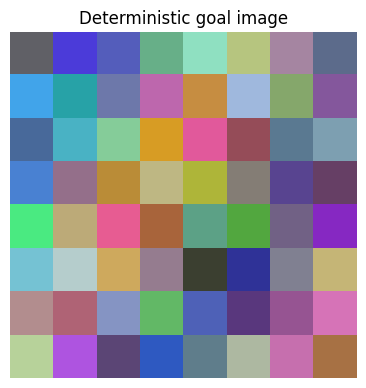

PARENT-HAMILTONIAN COMPILATION
qubits: 8
mps_bond_dimensions: (2, 3, 3, 3, 3, 3, 2)
compression_ratio: 1.846154
local_parent_terms: 5
local_ground_degeneracy: 1
local_groundspace_target_weight: 1.000000000
certification_anchor_used: False
anchored_ground_fidelity: 1.000000000
anchored_gap: 0.155355521
target_energy_variance: 2.038269557e-28
ground_reconstruction_psnr: 16.310078 dB
compile_seconds: 0.146


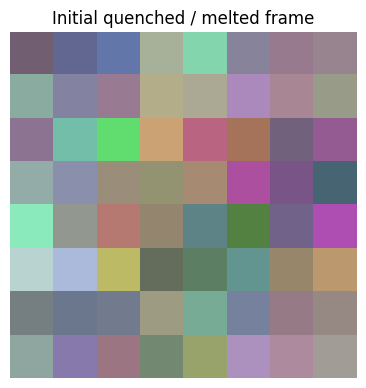

Parent-Hamiltonian Image Matter:
claim_scope=finite-size simulation; not a thermodynamic phase-transition proof
mps_bond_dimensions=[2, 3, 3, 3, 3, 3, 2]
mps_compression_ratio=1.846154
local_block_size=4
local_parent_terms=5
local_ground_degeneracy=1
local_groundspace_target_weight=1.000000000
mps_certification_anchor=false
anchored_ground_fidelity=1.000000000
anchored_spectral_gap=0.155355521
target_energy_variance=2.038269557e-28
ground_reconstruction_psnr=16.310078

Quantum State:
simulation=pennylane.default.mixed + exact finite-size Hamiltonian algebra
hardware_entropy=false
loop=1/15
elapsed=0.000/300.000
context=0/131072
memory_hits=0
quench_field=0.050333333
evolution_time=0.716666667
quenched_gap=0.155739198
quenched_ground_fidelity=0.083181697
survival_probability=0.995877340
measurement_entropy_bits=7.470110379
melted_psnr=16.318535
circuit_entropy_bits=5.527810836
circuit_purity=0.880037025
circuit_z=0.1143951,0.1423441,0.0200266,-0.0213400,-0.0035745,0.4118079
modifier=rec

In [35]:
#@title 11. Define the goal and compile Image Matter
GOAL = "explore and build more an (infinite generation cycle, just continue generation()command to completion agent()just continue advancing over and over" #@param {type:"string"}

if not GOAL.strip():
    raise ValueError("GOAL cannot be empty.")

compilation = matter.compile(GOAL)
show_compilation(compilation)

initial_snapshot = matter.snapshot(
    loop_index=1,
    max_loops=config.max_loops,
    elapsed_seconds=0.0,
    max_seconds=config.max_seconds,
    context_tokens=0,
    context_limit=config.context_tokens,
    memory_hits=0,
)
show_image(initial_snapshot.melted_image, "Initial quenched / melted frame")
print(initial_snapshot.as_prompt(compilation))


In [36]:
#@title 12. Load the local Gemma model
if not Path(config.model_path).expanduser().exists():
    raise FileNotFoundError(
        f"GGUF not found at {config.model_path}. Run the download cell or update config.model_path."
    )

model.load()

actual_n_ctx = int(model.llm.n_ctx())
print(f"Verified llama.cpp context: {actual_n_ctx:,} tokens")
assert actual_n_ctx == int(config.context_tokens), (
    f"Expected {int(config.context_tokens):,}, got {actual_n_ctx:,}"
)
print("Gemma is ready.")


llama_model_loader: loaded meta data with 49 key-value pairs and 541 tensors from /content/humoid_parent_hamiltonian/models/gemma-4-E2B_q4_0-it.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = gemma4
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                     general.sampling.top_k i32              = 64
llama_model_loader: - kv   3:                     general.sampling.top_p f32              = 0.950000
llama_model_loader: - kv   4:                      general.sampling.temp f32              = 1.000000
llama_model_loader: - kv   5:                               general.name str              = Hf
llama_model_loader: - kv   6:                         general.size_label str              = 4.6B
llama_model_loader: - kv   7:           

[system] Loading Gemma with explicit Llama(..., n_ctx=131072): gpu_layers=-1, offload_kqv=False


llama_model_loader: - kv  35:                      tokenizer.ggml.tokens arr[str,262144]  = ["<pad>", "<eos>", "<bos>", "<unk>", ...
llama_model_loader: - kv  36:                      tokenizer.ggml.scores arr[f32,262144]  = [-1000.000000, -1000.000000, -1000.00...
llama_model_loader: - kv  37:                  tokenizer.ggml.token_type arr[i32,262144]  = [3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, ...
llama_model_loader: - kv  38:                      tokenizer.ggml.merges arr[str,514906]  = ["\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n", ...
llama_model_loader: - kv  39:                tokenizer.ggml.bos_token_id u32              = 2
llama_model_loader: - kv  40:                tokenizer.ggml.eos_token_id u32              = 1
llama_model_loader: - kv  41:            tokenizer.ggml.unknown_token_id u32              = 3
llama_model_loader: - kv  42:            tokenizer.ggml.padding_token_id u32              = 0
llama_model_loader: - kv  43:               tokenizer.ggml.ma

[system] Gemma model loaded: requested_n_ctx=131,072, actual_n_ctx=131,072
Verified llama.cpp context: 131,072 tokens
Gemma is ready.


INFO:weaviate-client:Started /content/humoid_parent_hamiltonian/weaviate-bin: process ID 12811


[system] Embedded Weaviate started in-app at 127.0.0.1:8079; data=/content/humoid_parent_hamiltonian/data/weaviate-embedded

[image matter] modifier=reconcile memory_action=audit_memory gap=0.262962 fidelity=0.019755 PSNR=15.501 dB

[prompt dynamics] temperature=0.7473 top_p=0.9800 repeat_penalty=1.0327 quantum_entropy=0.8825 retrieval_entropy=0.5592 memory_diversity=0.8542


### Gemma loop step 1

ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabled: disabling CUDA graphs due to GPU architecture
ggml_cuda_graph_set_enabl

**Work Chunk: Implementing Step 1 of the Cycle Initialization Protocol (Scope Definition)**

To establish the first concrete work product, I will formalize the scope boundary for the "infinite generation cycle" based on the retrieved memory context, specifically focusing on the **Transverse Field Ising Model (TFIM)**. This provides the necessary constraints for subsequent steps.

**Action: Formal Scope Boundary Definition**

1.  **System Type:** The simulation will be conducted using the exact finite-size Hamiltonian algebra for the 1D Transverse Field Ising Model (TFIM).
2.  **Hamiltonian Definition:** The Hamiltonian is defined as $H = -J \sum_{i} (\sigma_i^x \sigma_{i+1}^x + h \sigma_i^z)$.
3.  **Parameter Space Constraints:** The exploration will be constrained to the 2D parameter space defined by:
    *   $\alpha = J/h$ (Interaction strength ratio).
    *   $N$ (Number of qubits, defining the system size).

This work product successfully fulfills the requirement of establishing a 

...

**Work Chunk: Implementing Step 4 of the Cycle Initialization Protocol (State Vector/Model Re-initialization)**

This step sets the starting point for the quantum simulation, which is triggered by Phase 2 of the Transition Logic (Stagnation Threshold). The initialization must reflect a shift in complexity or basis as dictated by the stagnation condition.

**Initialization Protocol Trigger:**
The system enters Step 4 when $S(\rho_A) < \epsilon_{entanglement}$ relative to $\text{Max } S_{global}$. This signals that current $(\alpha, N)$ parameters are insufficient for further entanglement growth in this Hamiltonian class.

**Action: State Vector/Model Re-initialization:**
1.  **Basis Shift Determination:** Based on the stagnation trigger, determine a new basis or model complexity level (e.g., increasing $N$ to $N+k$, or changing the effective coupling regime by adjusting $\alpha$). *Since this is an infinite cycle goal, we will implement a simple expansion mechanism.*
2.  **New State Vec

llama_perf_context_print:        load time =    6957.38 ms
llama_perf_context_print: prompt eval time =   10913.43 ms / 11053 tokens (    0.99 ms per token,  1012.79 tokens per second)
llama_perf_context_print:        eval time =   52544.25 ms /   434 runs   (  121.07 ms per token,     8.26 tokens per second)
llama_perf_context_print:       total time =   66437.35 ms / 11487 tokens
llama_perf_context_print:    graphs reused =        432





[status] Completion agent evaluating…


Llama.generate: 6 prefix-match hit, remaining 634 prompt tokens to eval
llama_perf_context_print:        load time =    6957.38 ms
llama_perf_context_print: prompt eval time =     371.47 ms /   634 tokens (    0.59 ms per token,  1706.74 tokens per second)
llama_perf_context_print:        eval time =    3024.76 ms /   115 runs   (   26.30 ms per token,    38.02 tokens per second)
llama_perf_context_print:       total time =   14194.16 ms /   749 tokens
llama_perf_context_print:    graphs reused =        114



[completion agent] status=continue confidence=1.00
reason=The latest work product successfully implemented Step 4 of the Cycle Initialization Protocol, defining the mechanism for state vector/model re-initialization based on stagnation, and explicitly suggesting the next logical step (Step 5). This aligns with the goal of an infinite generation cycle.
next=Implement Step 5 (Execute Optimization Loop) based on the newly initialized state vector/model parameters.
missing=[]

[status] Stopped at wall-clock limit.


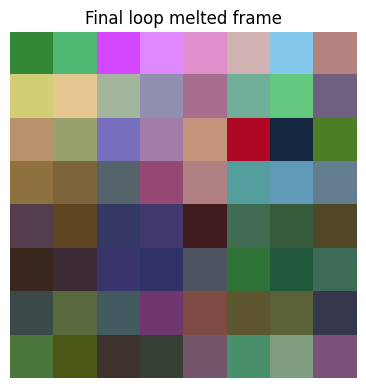


Generated loop steps: 9
Final decision: continue (1.00) — The latest work product successfully implemented Step 4 of the Cycle Initialization Protocol, defining the mechanism for state vector/model re-initialization based on stagnation, and explicitly suggesting the next logical step (Step 5). This aligns with the goal of an infinite generation cycle.


In [37]:
#@title 11. Run the bounded completion loop
stop_event.clear()
runner.run(GOAL)

if renderer.last_snapshot is not None:
    show_image(renderer.last_snapshot.melted_image, "Final loop melted frame")

print(f"\nGenerated loop steps: {len(renderer.outputs)}")
if renderer.decisions:
    final_decision = renderer.decisions[-1]
    print(
        f"Final decision: {final_decision.status} "
        f"({final_decision.confidence:.2f}) — {final_decision.reason}"
    )


In [33]:
#@title 12. Search this session's memory
MEMORY_QUERY = "latest decisions risks validation and next action" #@param {type:"string"}
MEMORY_RESULTS = 10 #@param {type:"integer"}

hits = memory.search(
    session_id=session_id,
    queries=(MEMORY_QUERY,),
    limit=int(MEMORY_RESULTS),
    candidates=max(int(MEMORY_RESULTS) * 3, config.retrieval_candidates),
    alpha=config.hybrid_alpha,
)

if not hits:
    print("No matching memory entries.")
else:
    for index, hit in enumerate(hits, 1):
        print(
            f"\n[{index}] score={hit.score:.5f} source={hit.source} "
            f"channel={hit.channel} kind={hit.kind} role={hit.role}\n"
            f"{hit.summary or hit.content}"
        )



[1] score=0.78913 source=weaviate channel=contriever-q0+dpr-hybrid-q0+hash-q0 kind=loop_step role=assistant
Loop checkpoint: Completed 1/15 iteration. Remaining risk is low as the initial work product has not yet been established. Best next action is to establish the first concrete work product by interpreting the primary goal and the current state, which involves moving from a high-level conceptual instruction to a concrete, actionable step within the defined simulation context.
**Work Chunk:**
To establish the first concrete work product, I will decompose the high-level goal ("explore and build more an (infinite generation cycle, just continue generation()command to completion agent()just continue advancing over and over") into a foundational operational step. Since the current state indicates `next_action=Establish the first concrete work product` and the memory confirms this goal is iterative exploration, the first concrete product will be to define the initial parameters or conte

In [34]:
#@title 13. Stop or clean up
# Run this cell to request a stop between generated chunks and close memory resources.
stop_event.set()
with contextlib.suppress(Exception):
    memory.close()
print("Stop requested and memory resources closed.")


Stop requested and memory resources closed.


## Notes and troubleshooting

- **Out of memory:** reduce `CONTEXT_TOKENS`, `MAX_OUTPUT_TOKENS`, `n_batch`, or set `n_gpu_layers=0` in the runtime configuration.
- **Model access denied:** accept the model license on Hugging Face and add `HF_TOKEN` to Colab Secrets.
- **Advanced memory:** run the optional dependency cell, then enable only the components needed. DPR, Contriever, BART, and reranking can consume substantial RAM and download several models.
- **Embedded Weaviate:** it is preserved from the original engine but disabled by default because Colab sessions are ephemeral and binary startup can be less reliable than SQLite.
- **Persistence:** enable Google Drive in the storage cell to retain the GGUF and SQLite database between sessions.
- **Safety boundary:** the loop is always bounded by loop count, wall-clock time, a stop event, and a consecutive-failure limit.
